# **EDA**

In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
ruta = "/content/drive/Shared drives/ETL_second_delivery/"

In [48]:
#instalar sweetviz para facilitar el EDA
!pip install -q sweetviz

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
from sweetviz import FeatureConfig
import warnings
warnings.filterwarnings("ignore")

#cargar los datasets transformados
df_fact   = pd.read_csv(ruta + "tf_fact.csv")
df_covid  = pd.read_csv(ruta + "tf_covid.csv")
df_uhc    = pd.read_csv(ruta + "tf_uhc.csv")
df_merged = pd.read_csv(ruta + "tf_merged.csv")

print()
for nombre, df in [("tf_fact", df_fact), ("tf_covid", df_covid),
                   ("tf_uhc", df_uhc), ("tf_merged", df_merged)]:
    print(f"{nombre:<12}: {df.shape[0]:>8,} filas  x  {df.shape[1]:>3} columnas")


tf_fact     :   66,320 filas  x   12 columnas
tf_covid    :    1,143 filas  x    5 columnas
tf_uhc      :       24 filas  x    2 columnas
tf_merged   :        1 filas  x    9 columnas


---
##Calidad de los datos



In [50]:
# Tabla resumen de calidad para los 4 datasets
resumen = []
for nombre, df in [("tf_fact", df_fact), ("tf_covid", df_covid),
                   ("tf_uhc", df_uhc), ("tf_merged", df_merged)]:
    nulos_total = df.isnull().sum().sum()
    cols_con_nulos = (df.isnull().sum() > 0).sum()
    resumen.append({
        "dataset"         : nombre,
        "filas"           : len(df),
        "columnas"        : df.shape[1],
        "nulos_total"     : nulos_total,
        "cols_con_nulos"  : cols_con_nulos,
        "duplicados"      : df.duplicated().sum(),
        "tipos"           : df.dtypes.value_counts().to_dict()
    })

df_quality = pd.DataFrame(resumen).drop(columns=["tipos"])
print("Resumen de calidad")
print(df_quality.to_string(index=False))

print("\n Nulos por columna ")
for nombre, df in [("tf_fact", df_fact), ("tf_covid", df_covid),
                   ("tf_uhc", df_uhc), ("tf_merged", df_merged)]:
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    if len(nulos) > 0:
        print(f"\n[{nombre}]")
        for col, n in nulos.items():
            print(f"  {col}: {n} nulos ({100*n/len(df):.1f}%)")
    else:
        print(f"\n[{nombre}] — sin nulos")

Resumen de calidad
  dataset  filas  columnas  nulos_total  cols_con_nulos  duplicados
  tf_fact  66320        12            0               0           0
 tf_covid   1143         5            0               0           0
   tf_uhc     24         2            0               0           0
tf_merged      1         9            0               0           0

 Nulos por columna 

[tf_fact] — sin nulos

[tf_covid] — sin nulos

[tf_uhc] — sin nulos

[tf_merged] — sin nulos


##Reportes automaticos con Sweetviz

Sweetviz genera un reporte HTML interactivo por dataset. Se guardan en drive para referencia.

                                             |          | [  0%]   00:00 -> (? left)

Report /content/drive/Shared drives/ETL_final_delivery/sweetviz_fact.html was generated.
Reporte tf_fact guardado en Drive



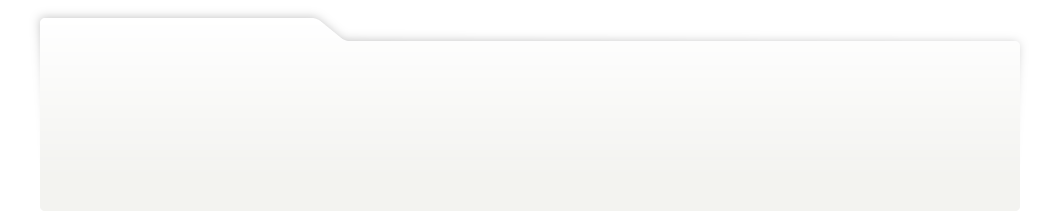
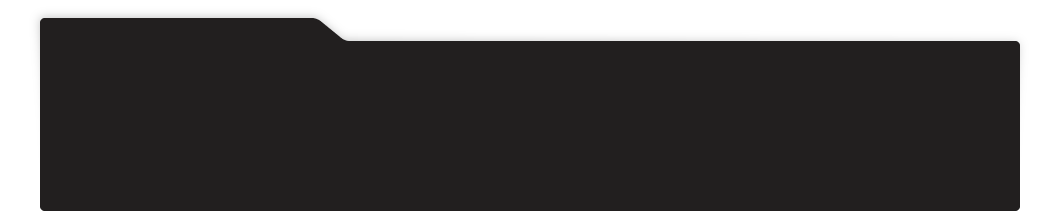
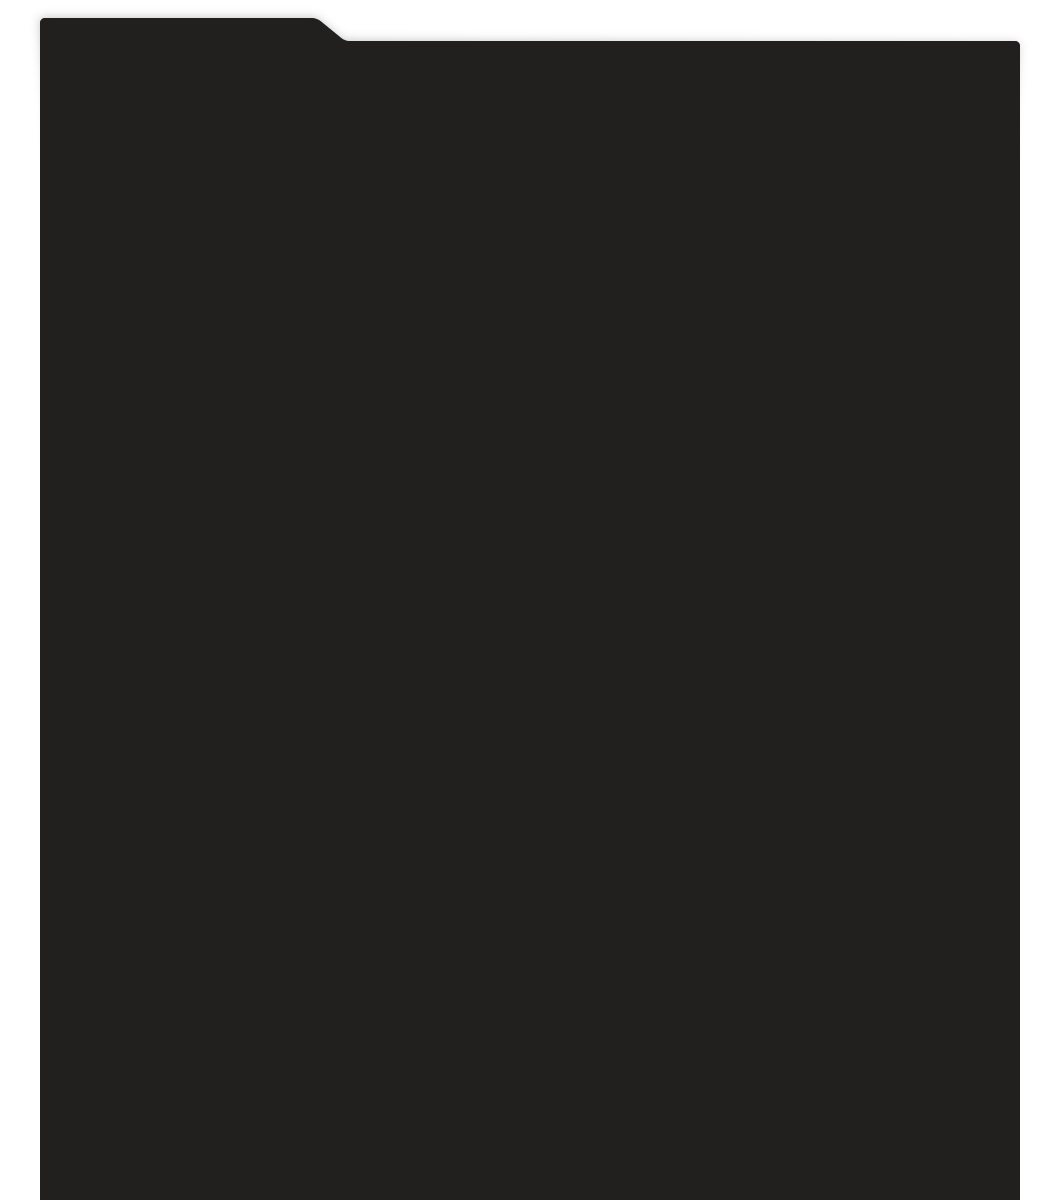
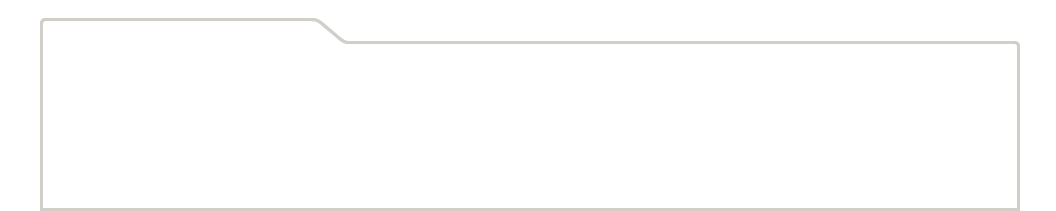
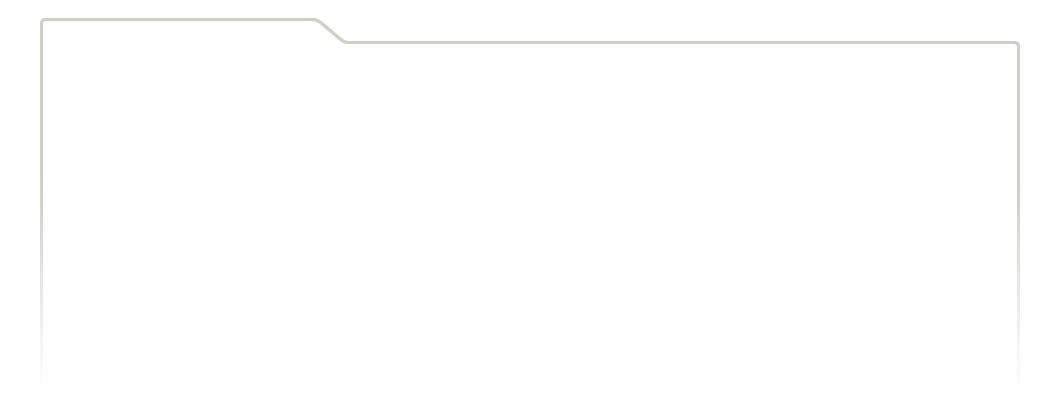
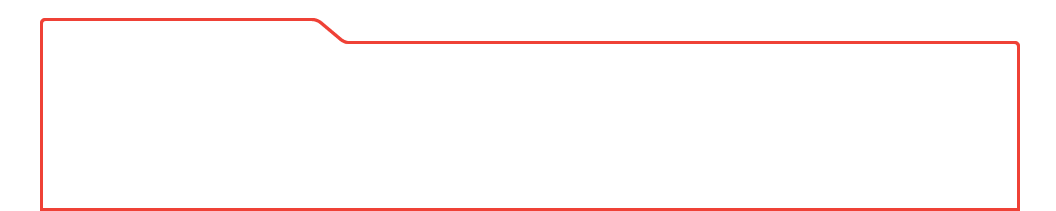
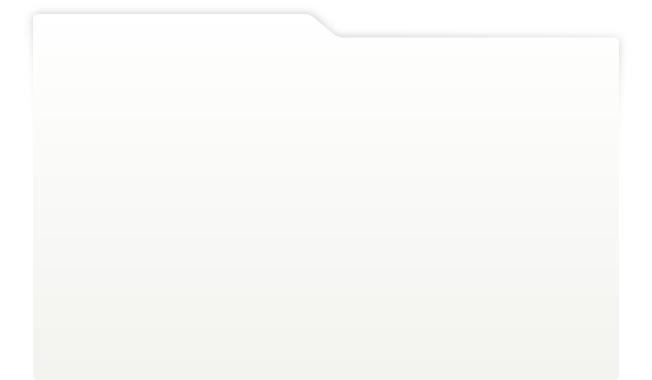
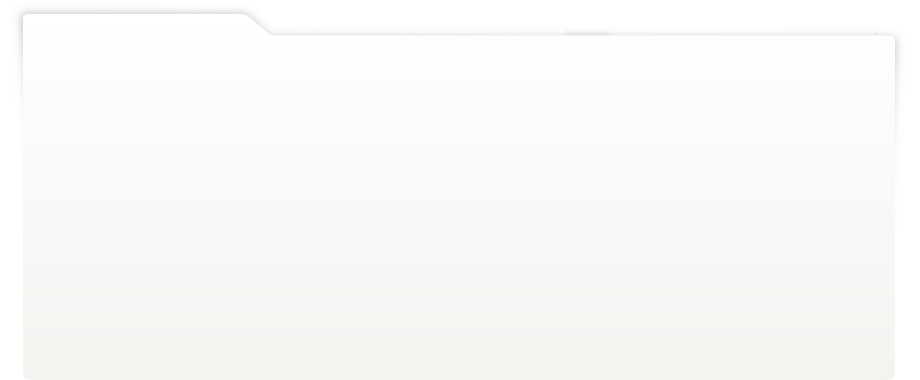
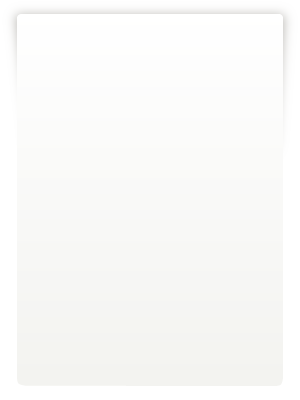
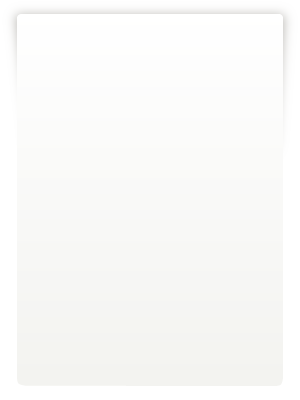
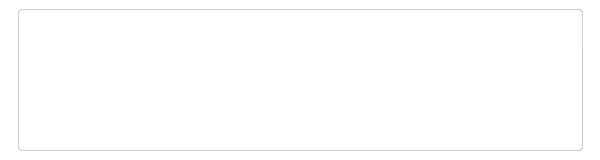
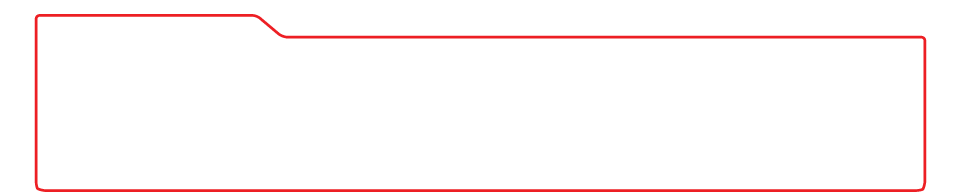
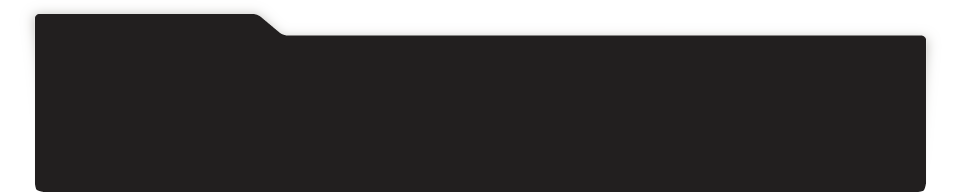
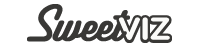
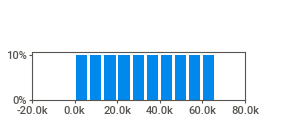
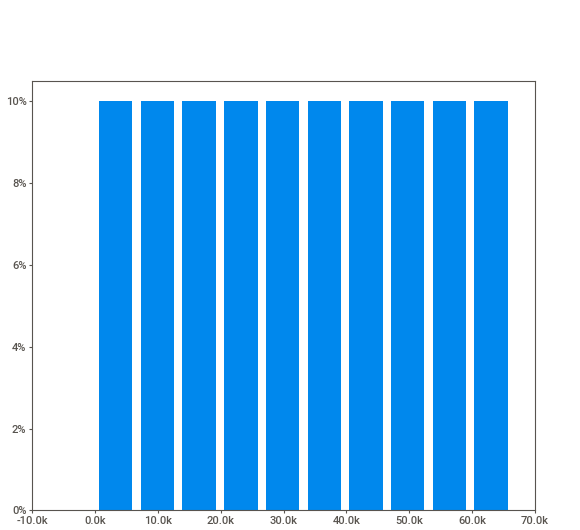
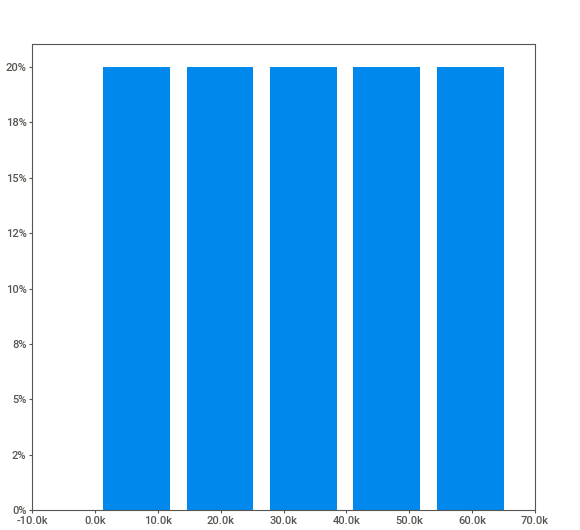
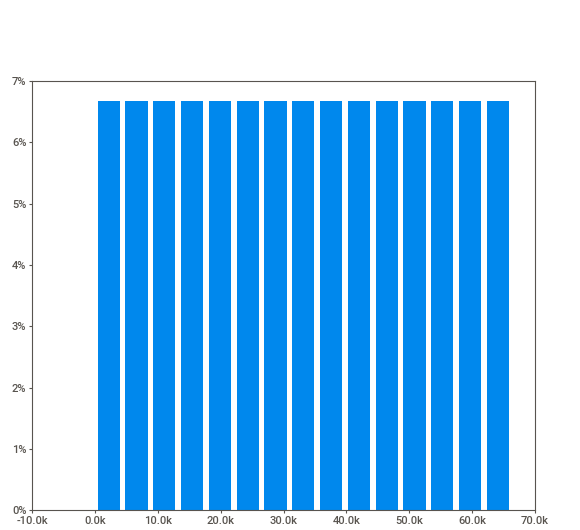
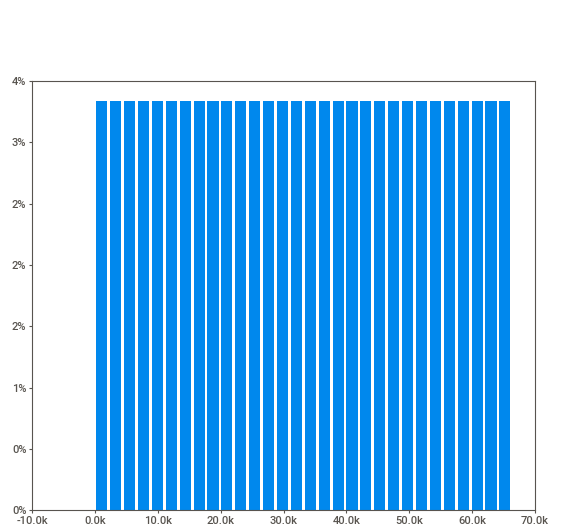
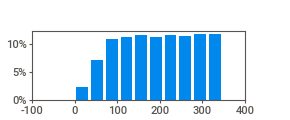
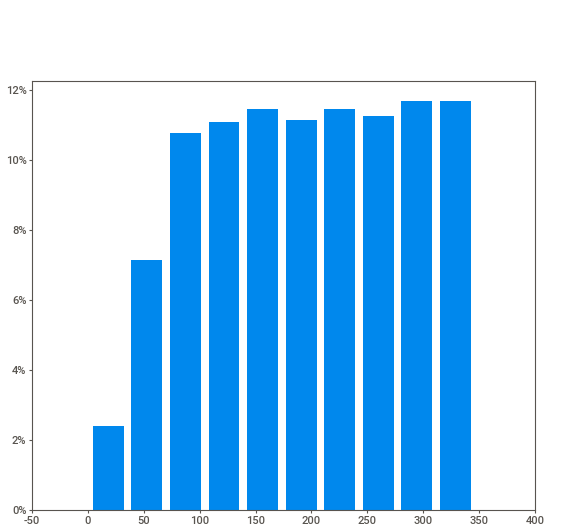
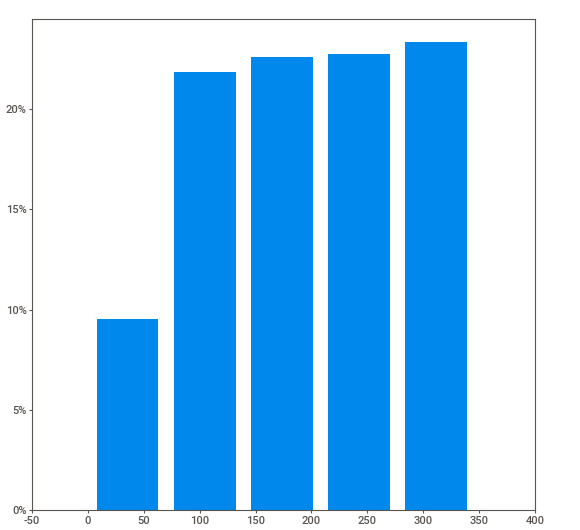
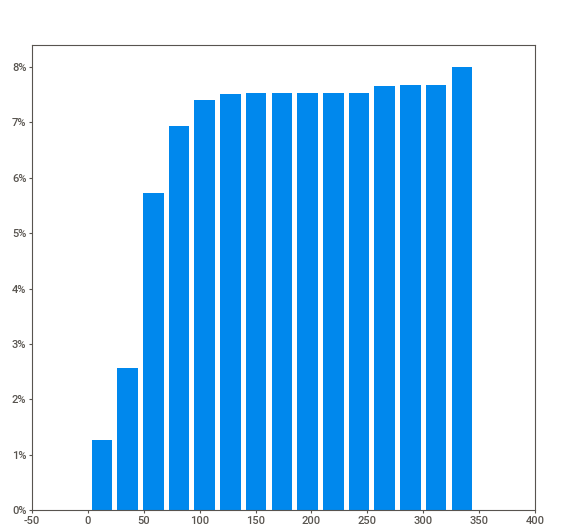
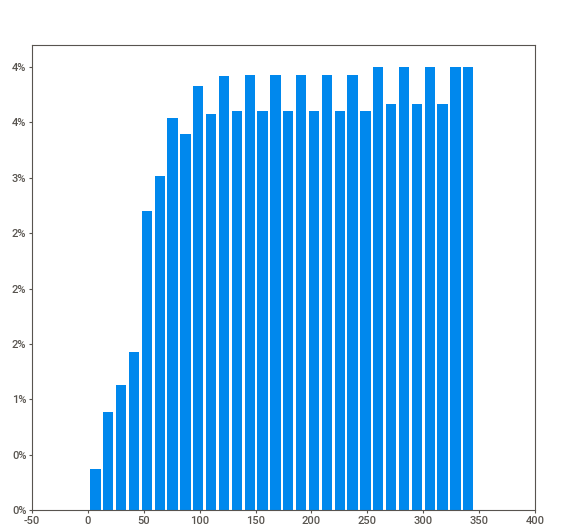
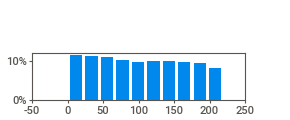
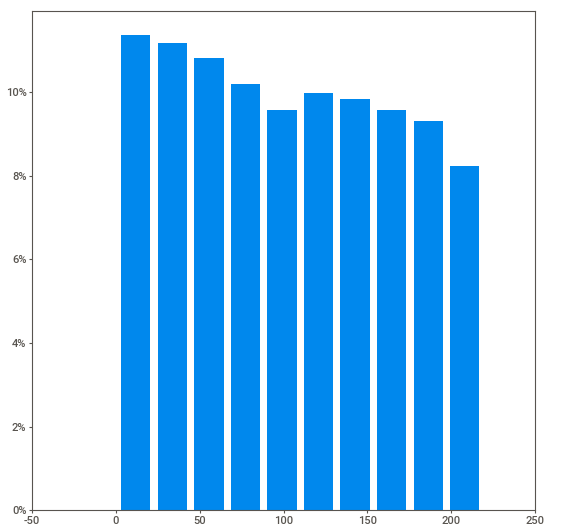
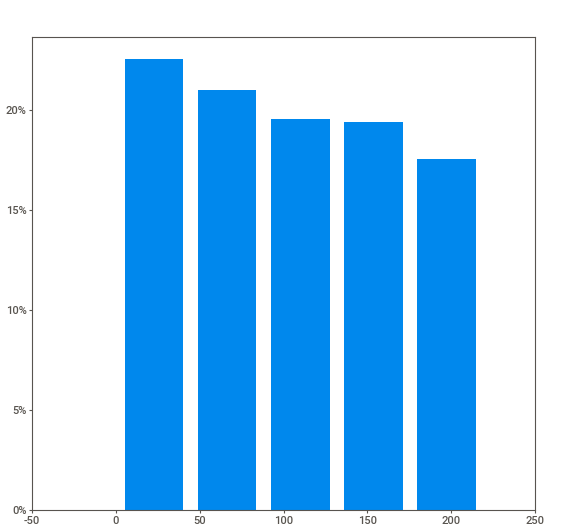
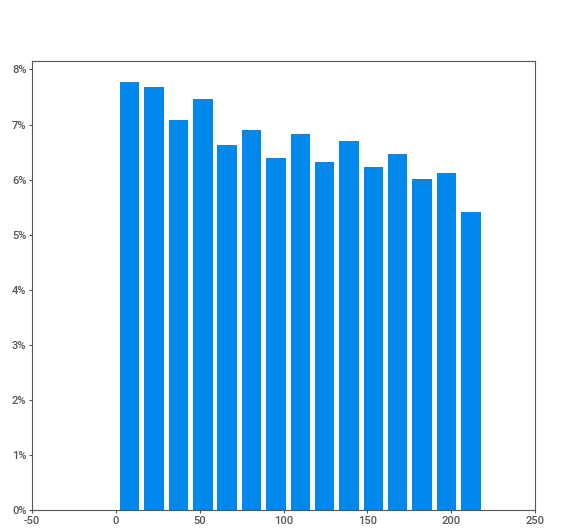
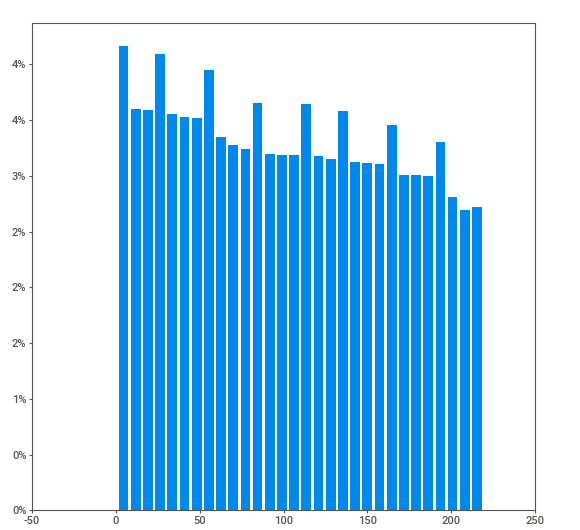
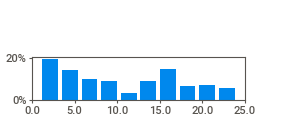
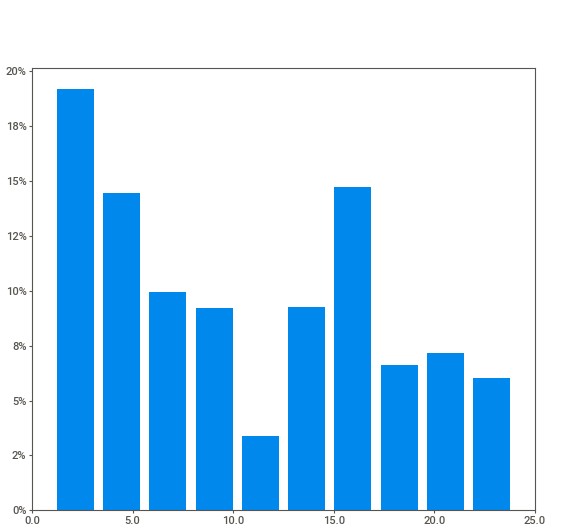
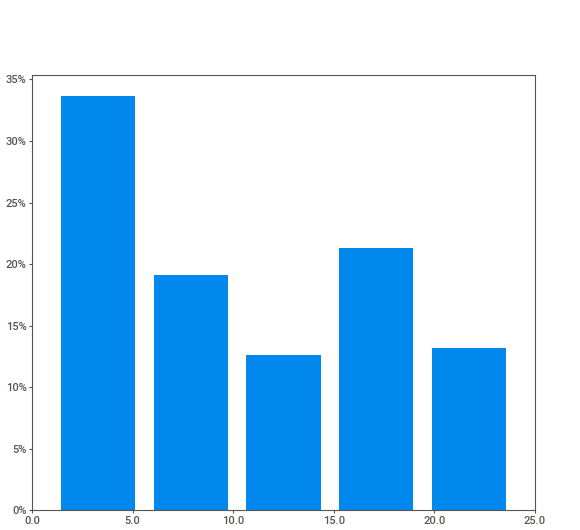
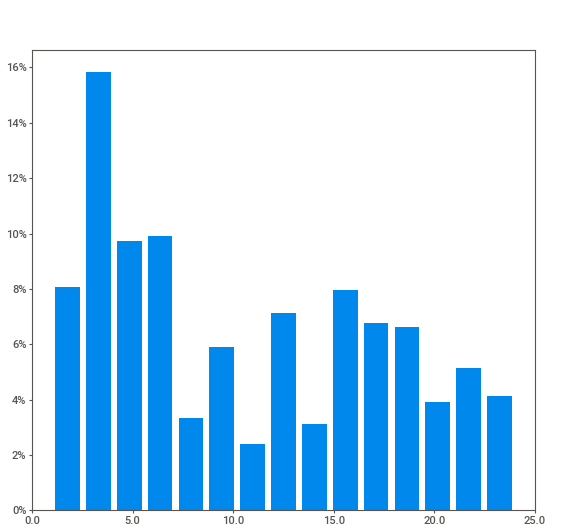
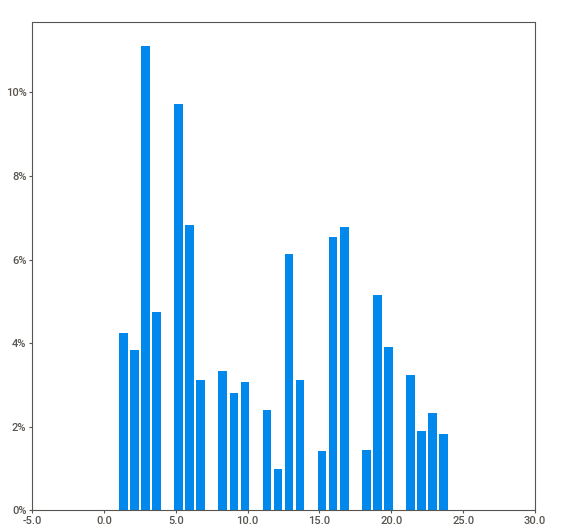
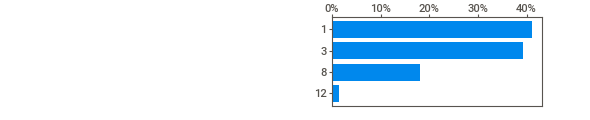
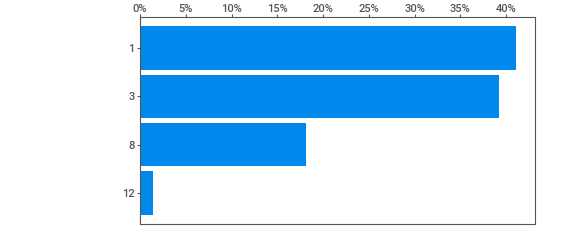
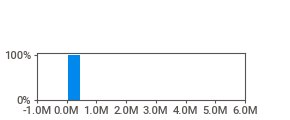
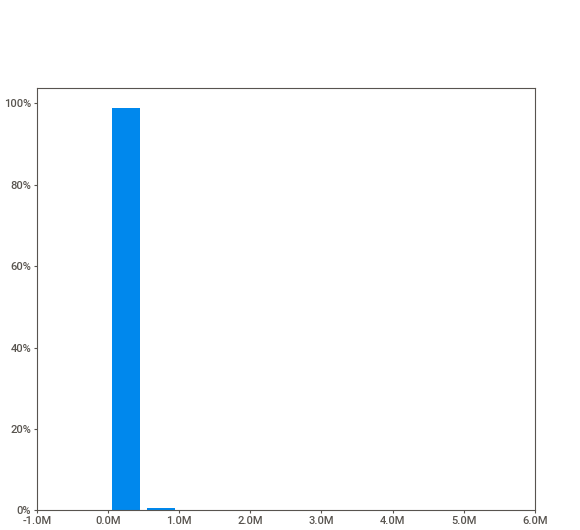
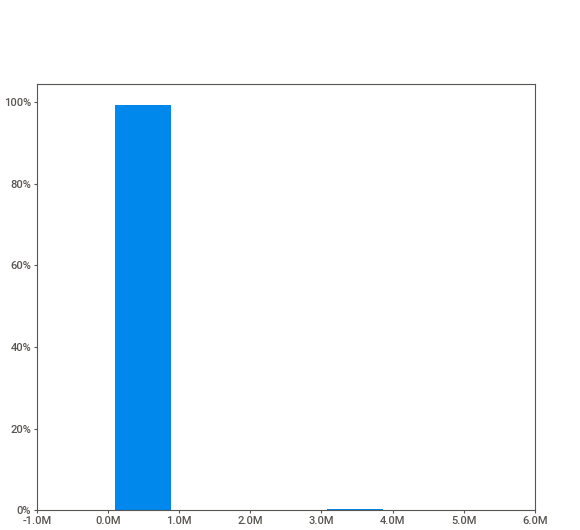
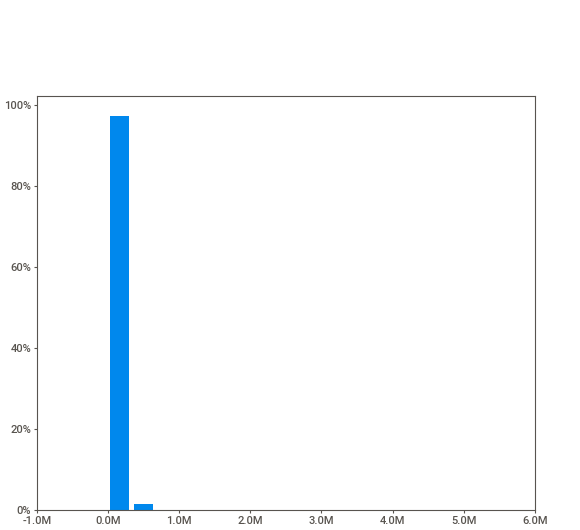
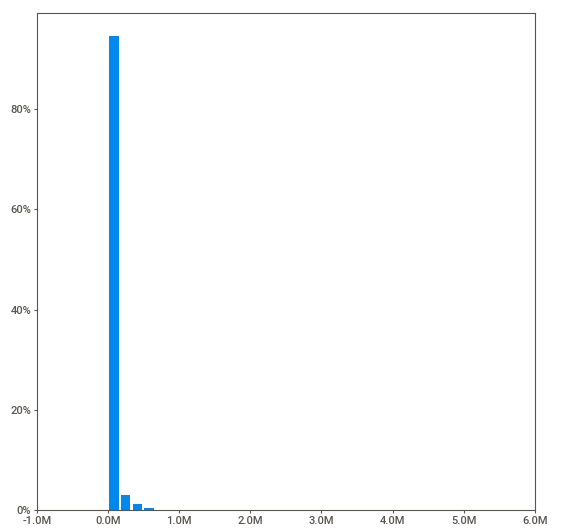
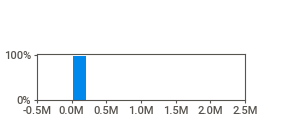
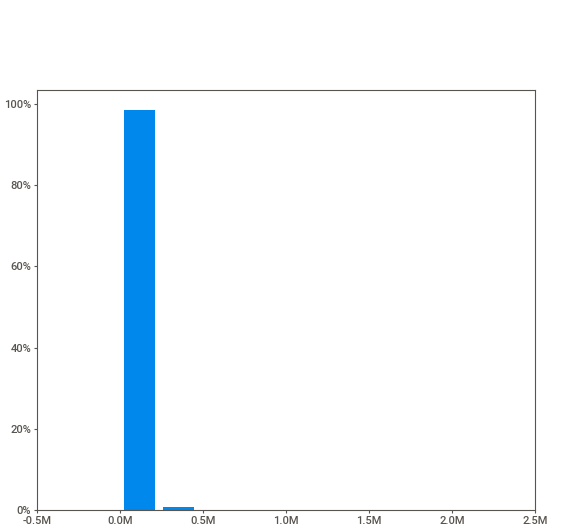
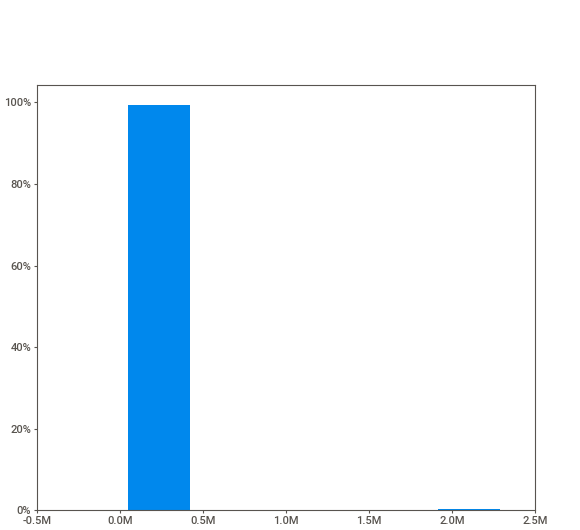
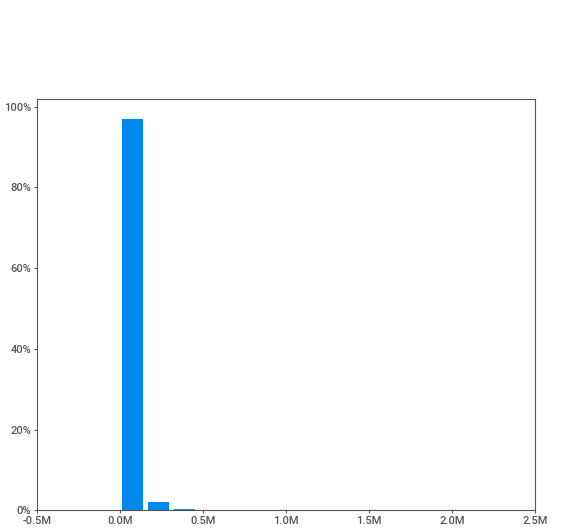
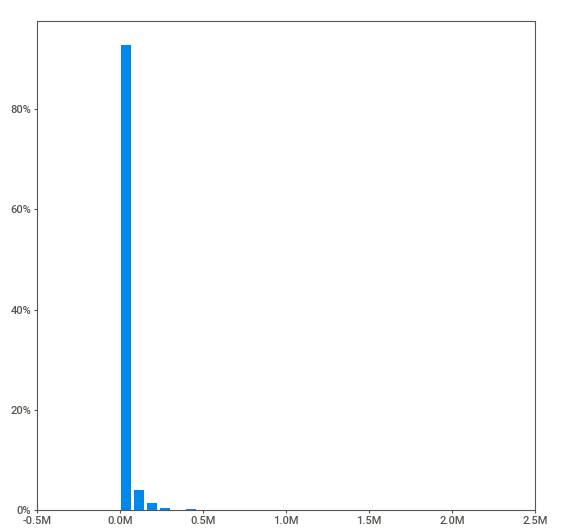
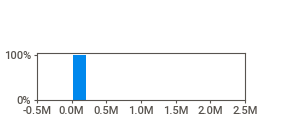
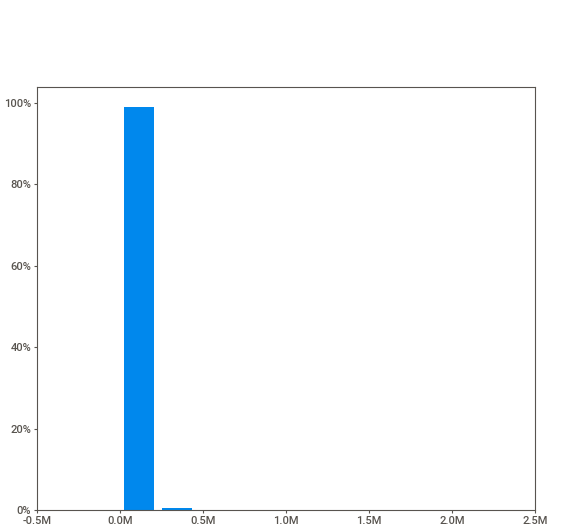
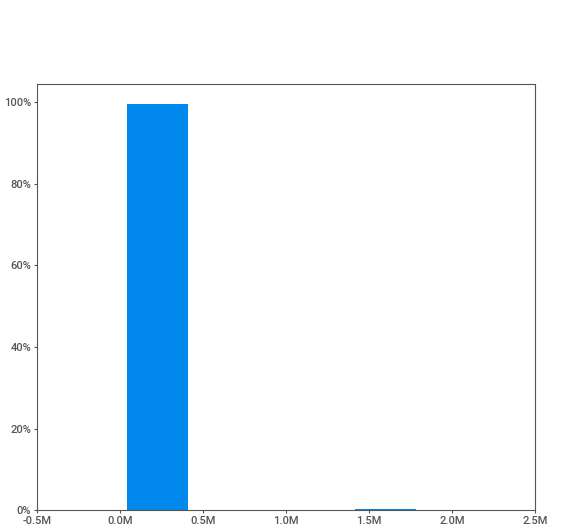
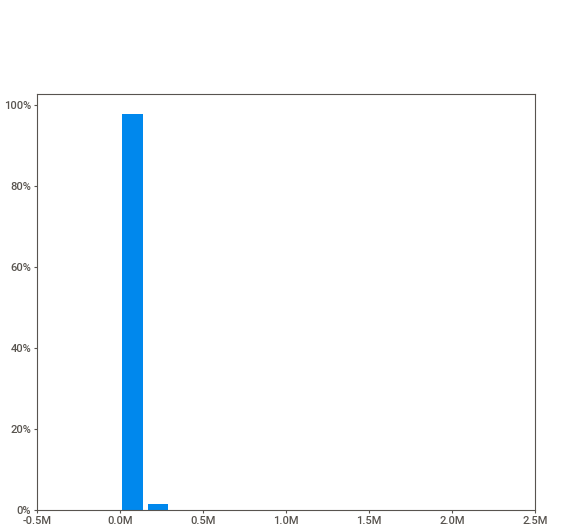
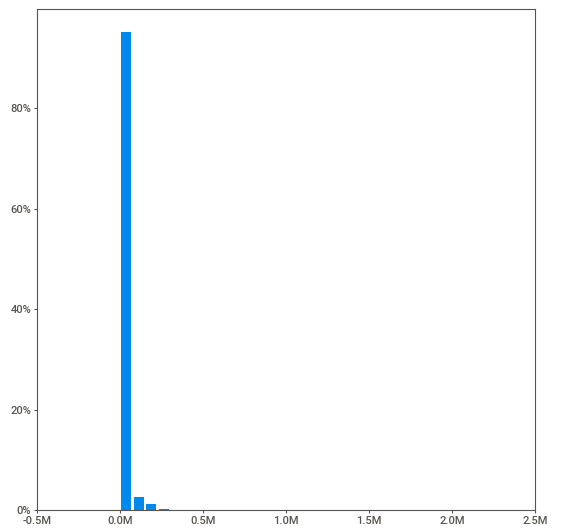
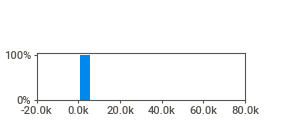
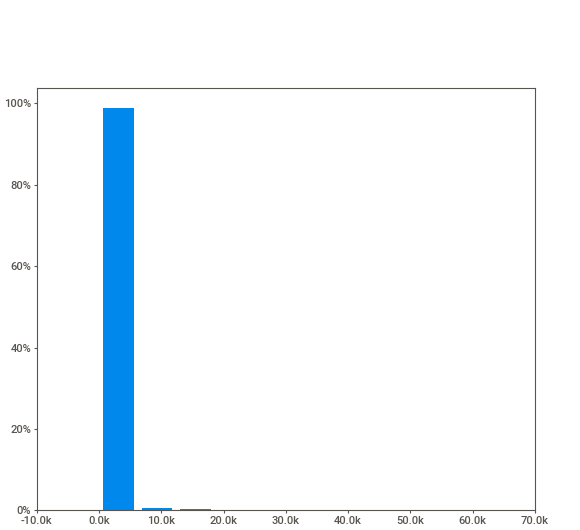
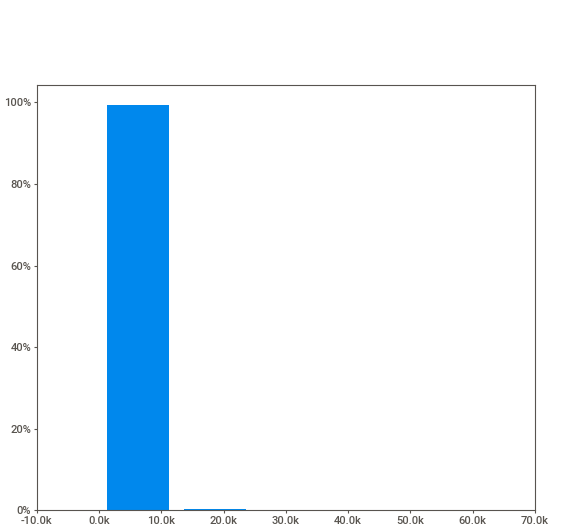
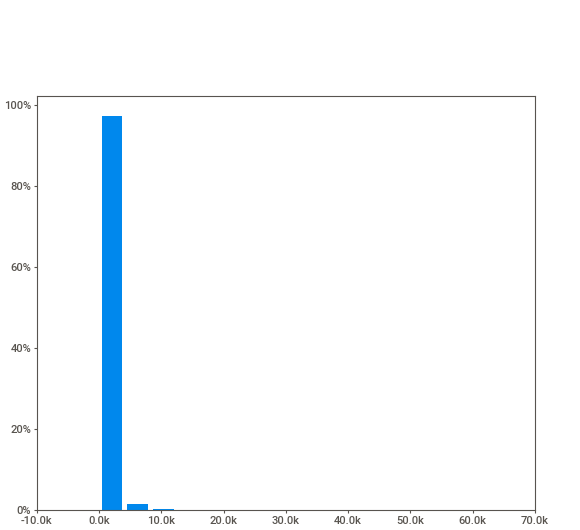
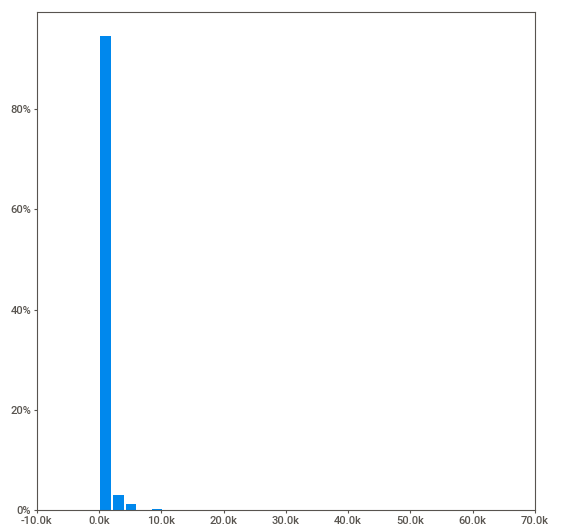
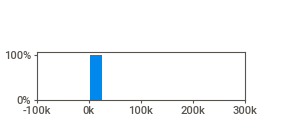
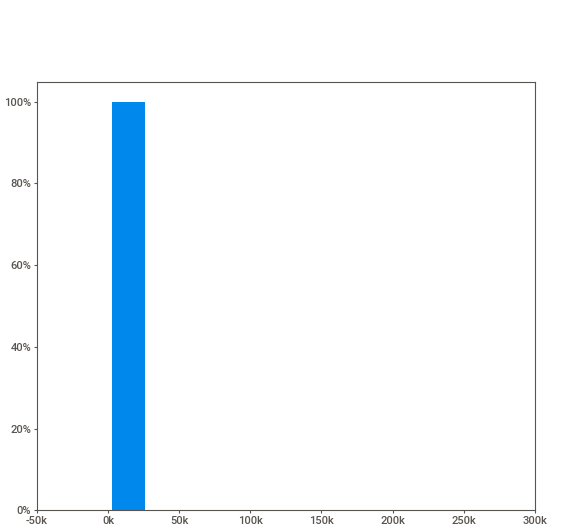
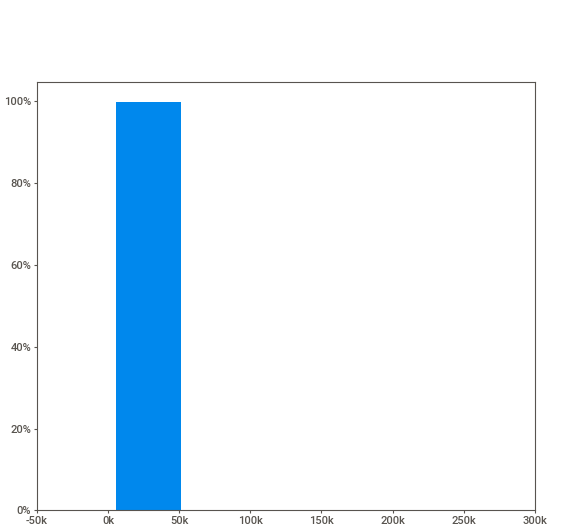
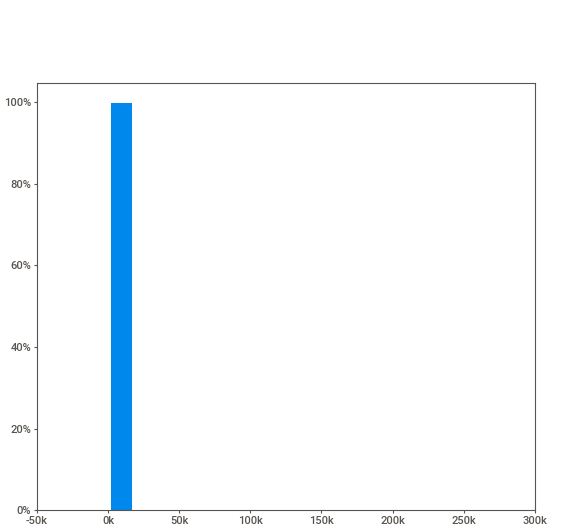
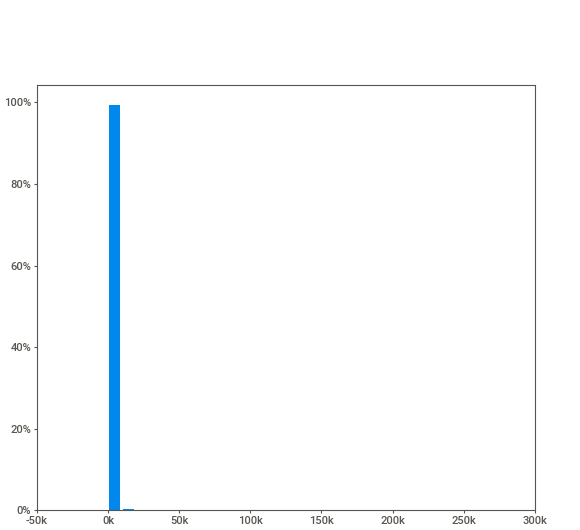
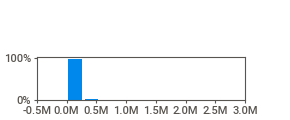
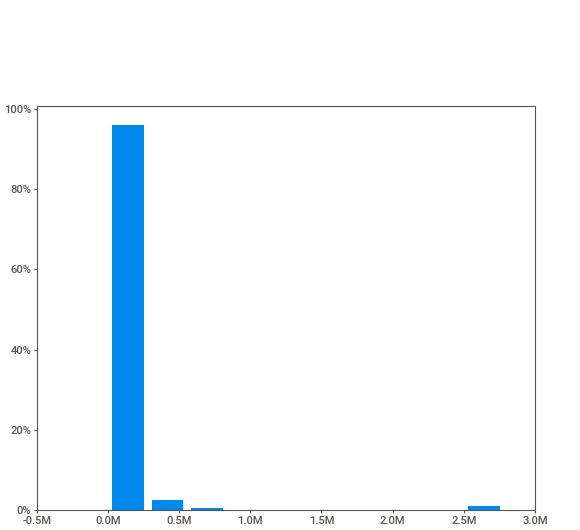
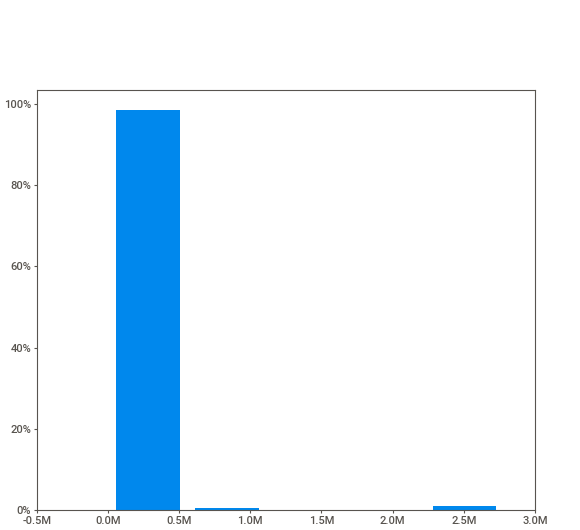
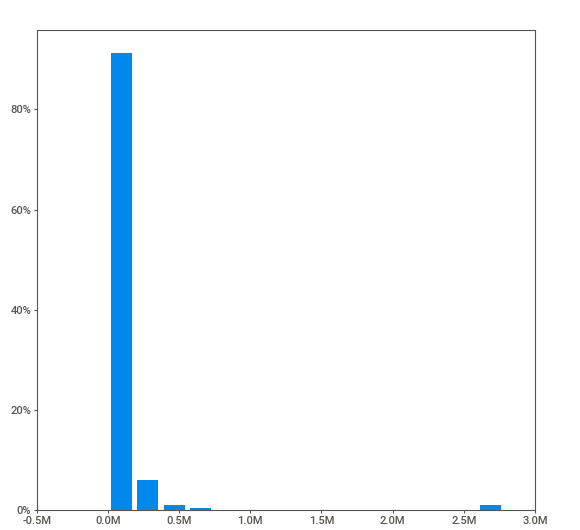
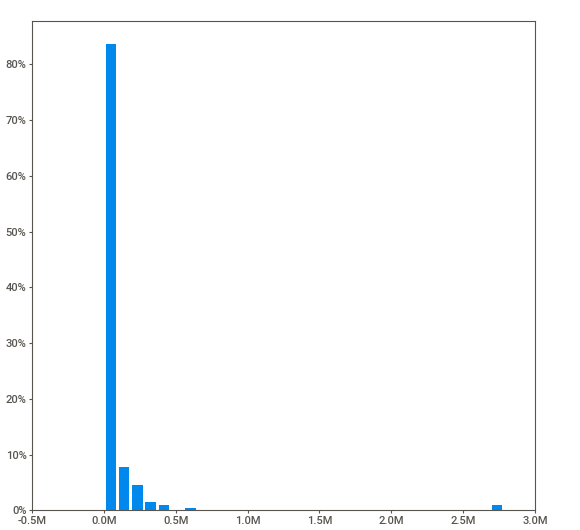
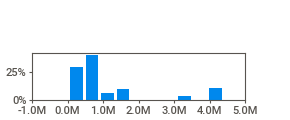
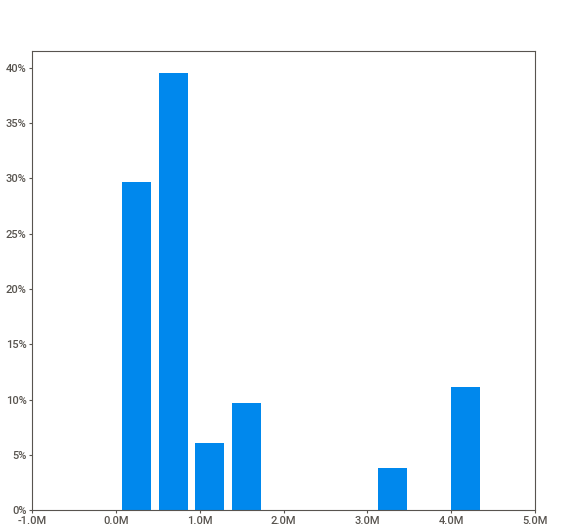
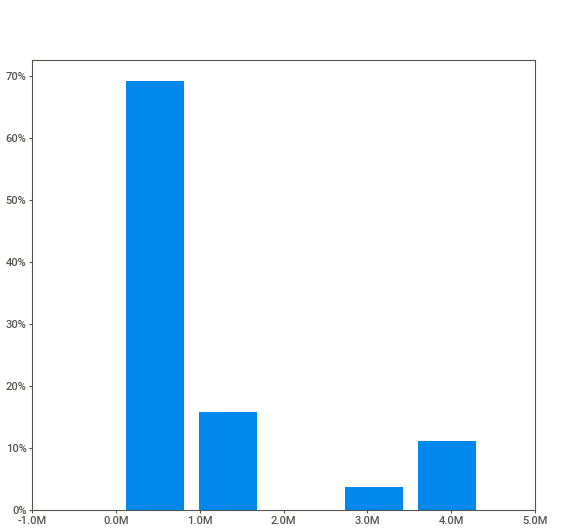
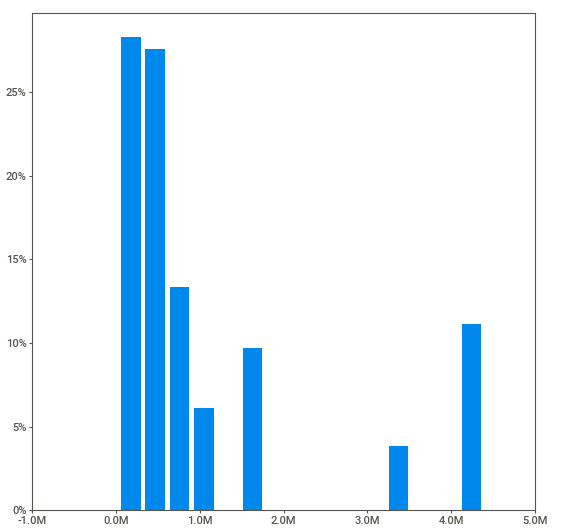
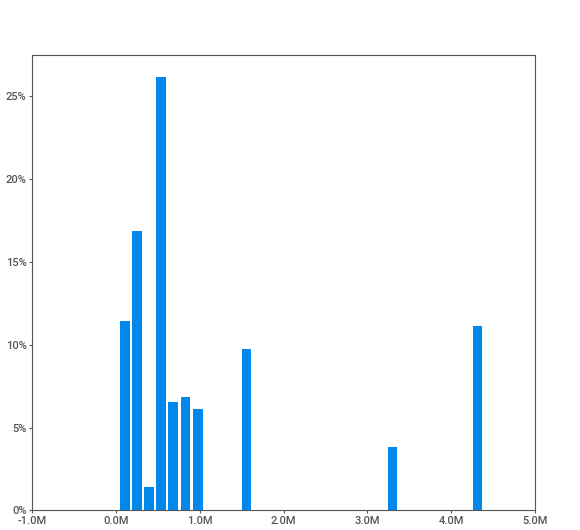
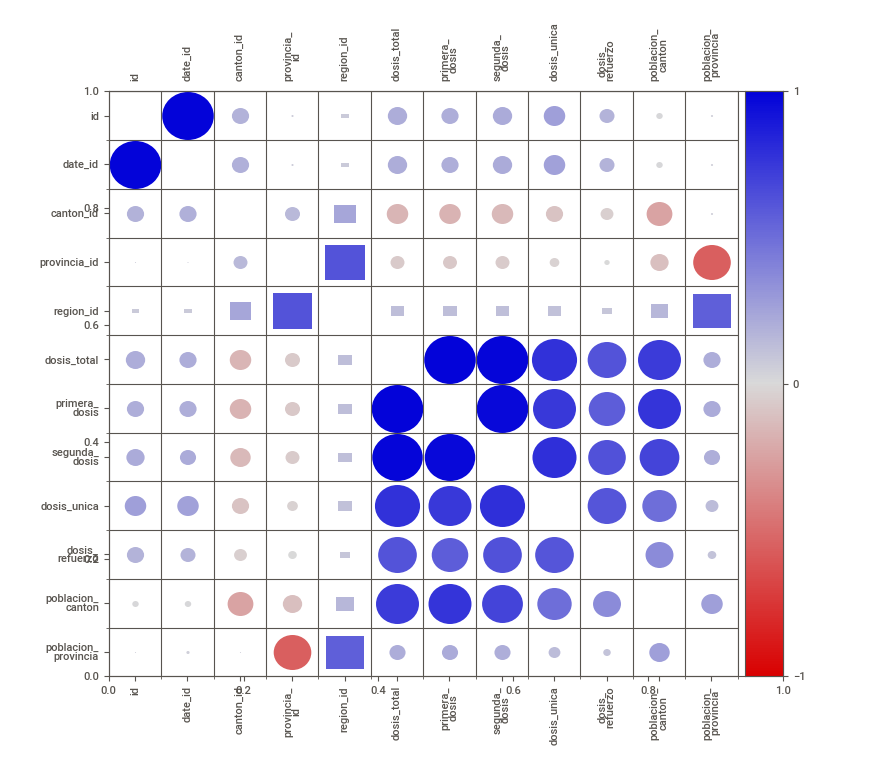
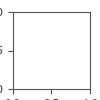

In [51]:
#Reporte 1: fact_vacunacion
# force_num asegura que las columnas de dosis se traten como numéricas
# (por si quedaron como object tras la carga desde CSV)
fc_fact = FeatureConfig(
    force_num=["dosis_total", "primera_dosis", "segunda_dosis",
               "dosis_unica", "dosis_refuerzo",
               "poblacion_canton", "poblacion_provincia"]
)
rep_fact = sv.analyze(df_fact, feat_cfg=fc_fact)
rep_fact.show_html("/content/drive/Shared drives/ETL_final_delivery/" + "sweetviz_fact.html", open_browser=False)
print("Reporte tf_fact guardado en Drive")
rep_fact.show_notebook()

                                             |          | [  0%]   00:00 -> (? left)

Report /content/drive/Shared drives/ETL_final_delivery/sweetviz_covid.html was generated.
Reporte tf_covid guardado en Drive ✓



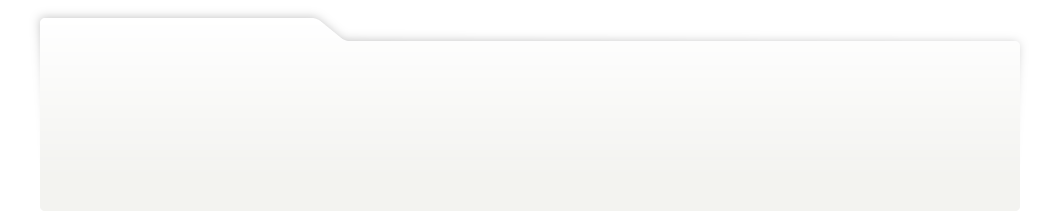
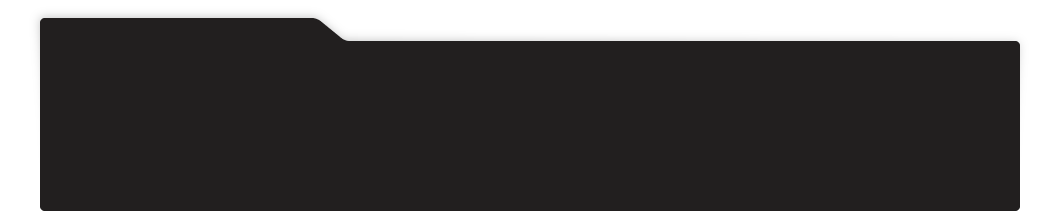
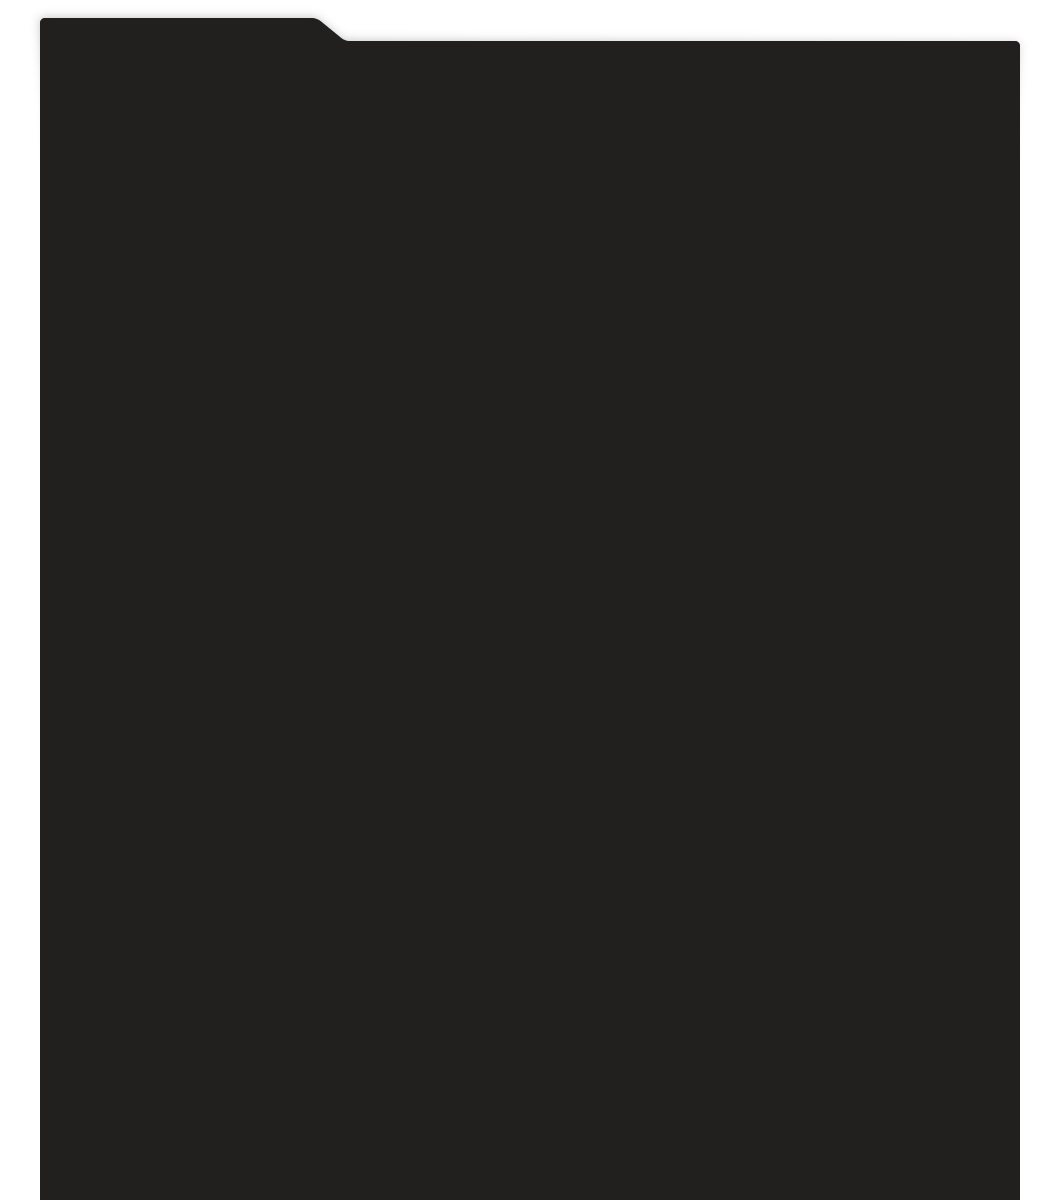
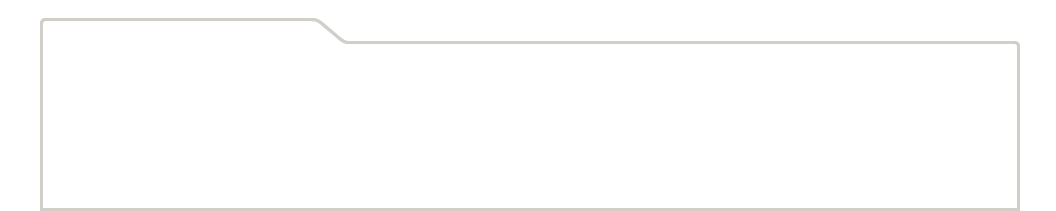
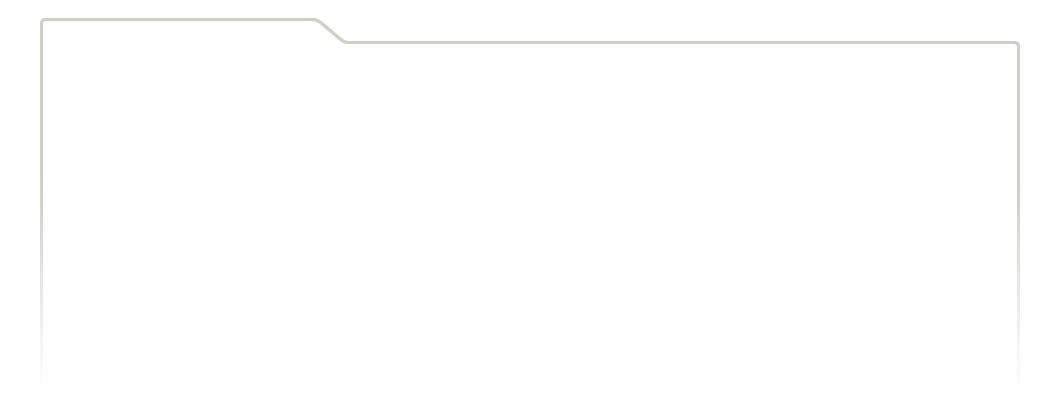
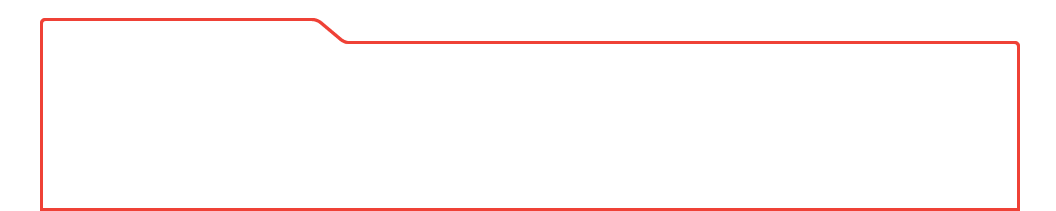
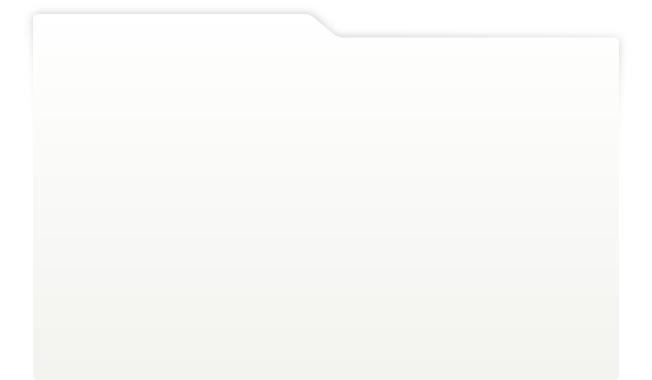
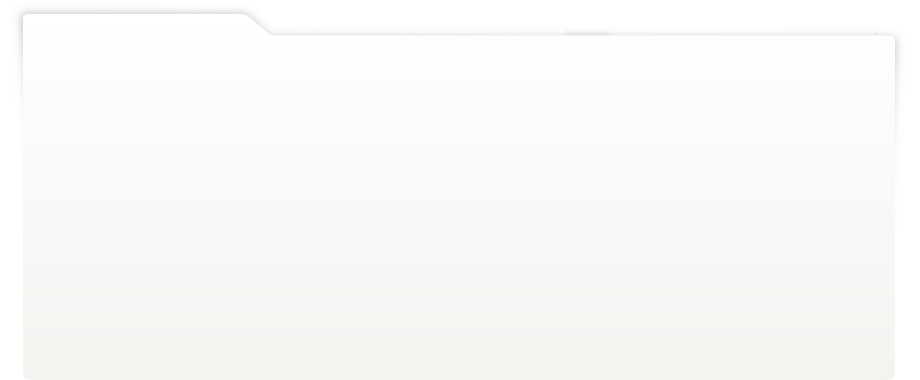
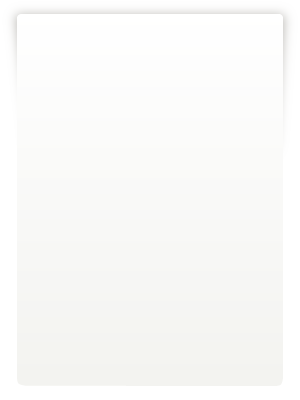
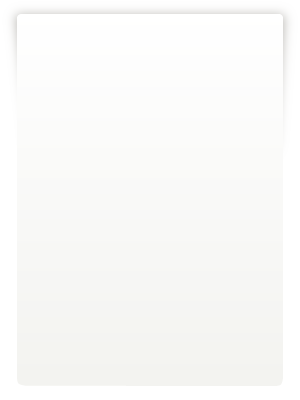
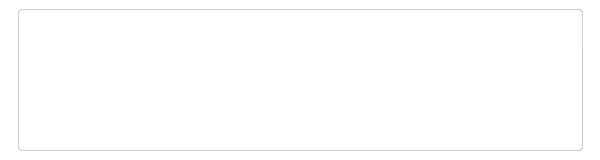
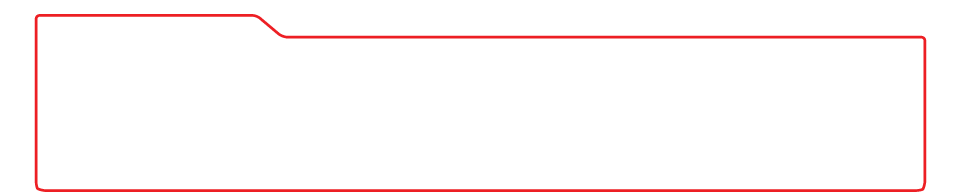
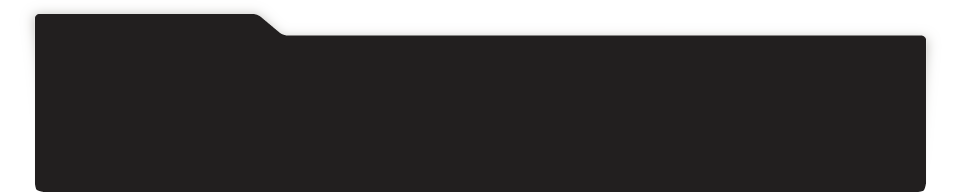
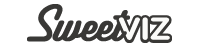
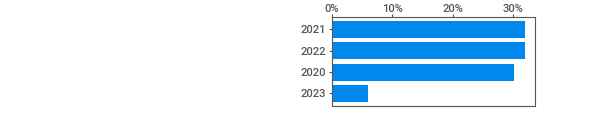
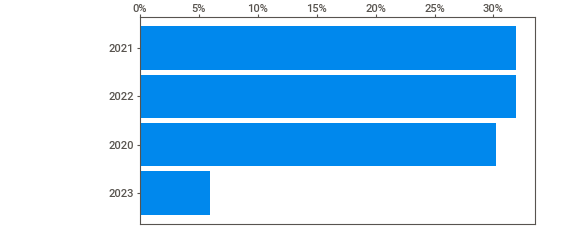
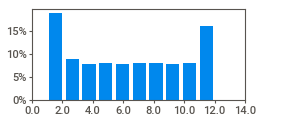
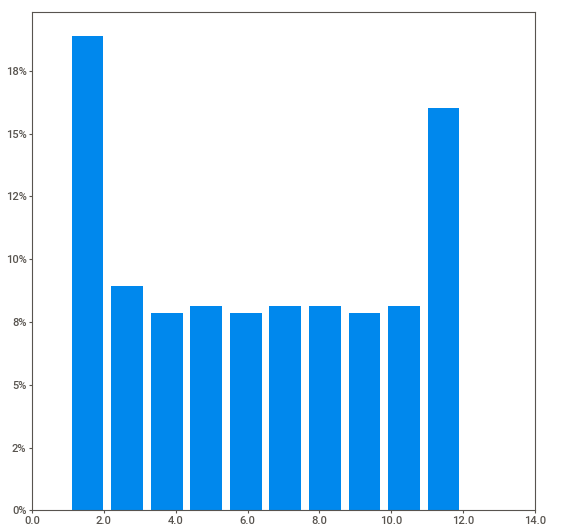
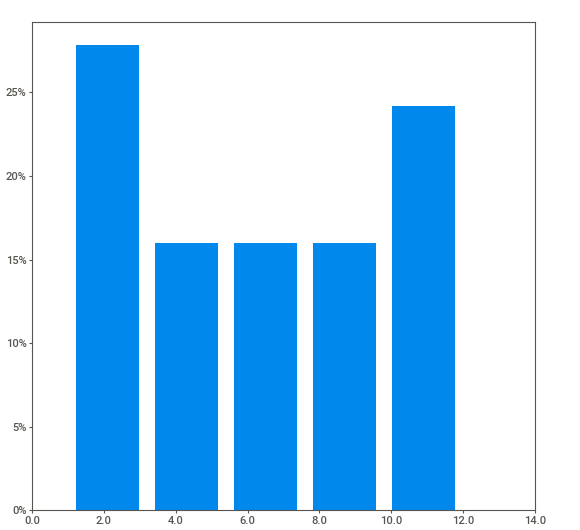
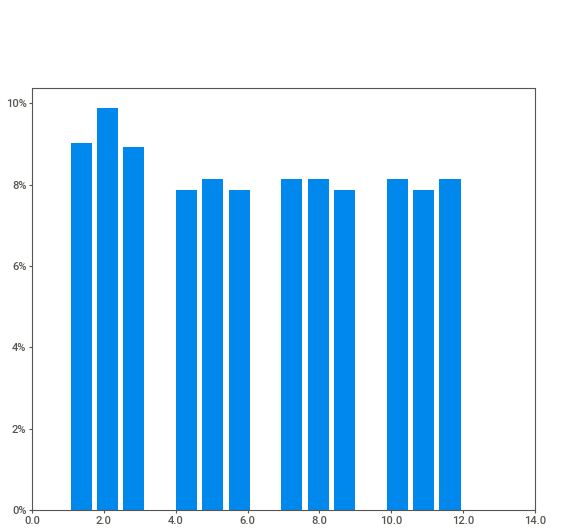
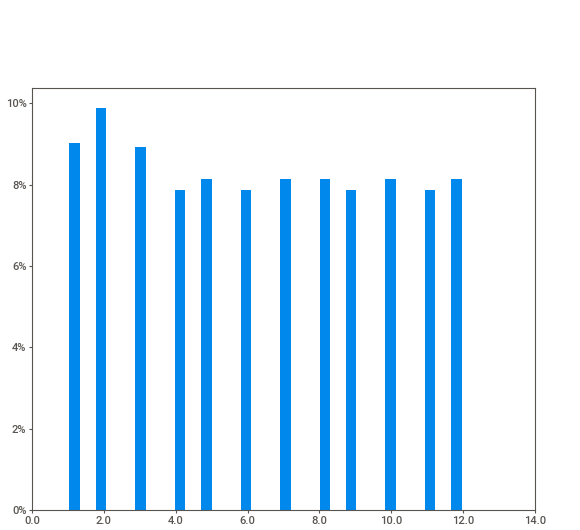
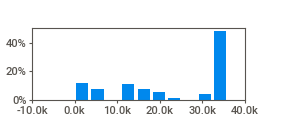
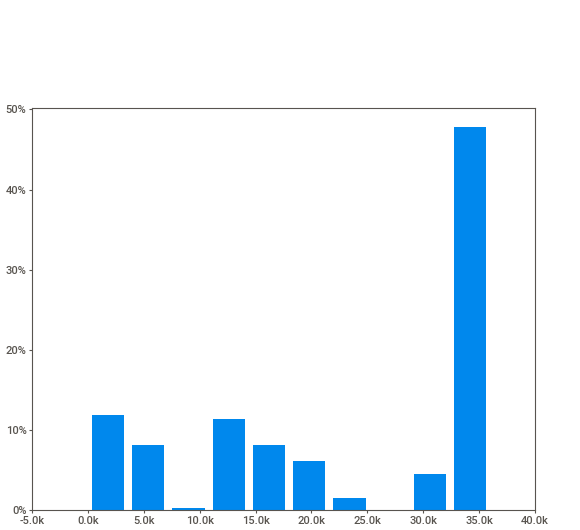
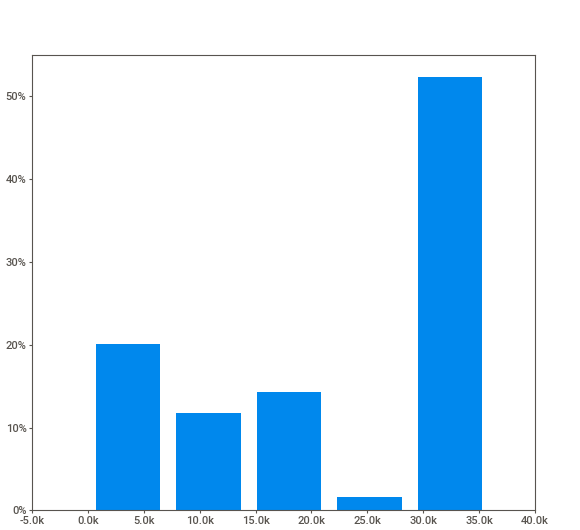
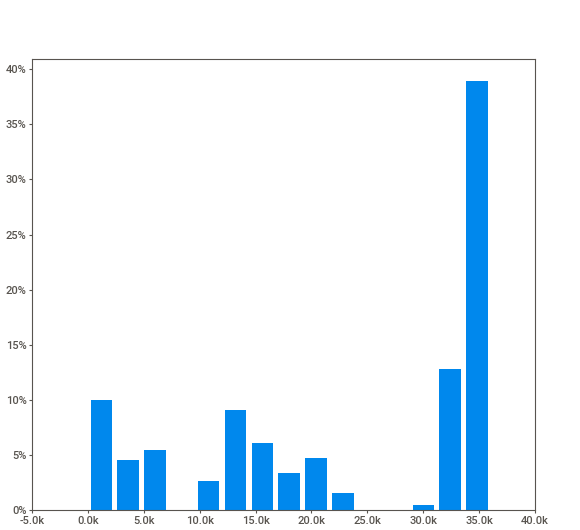
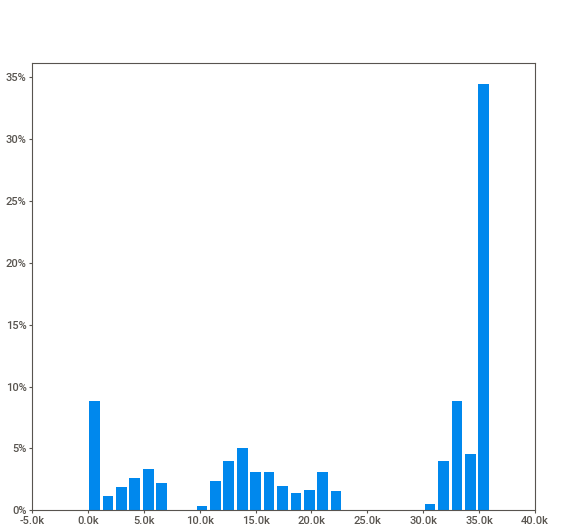
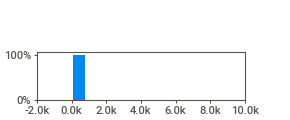
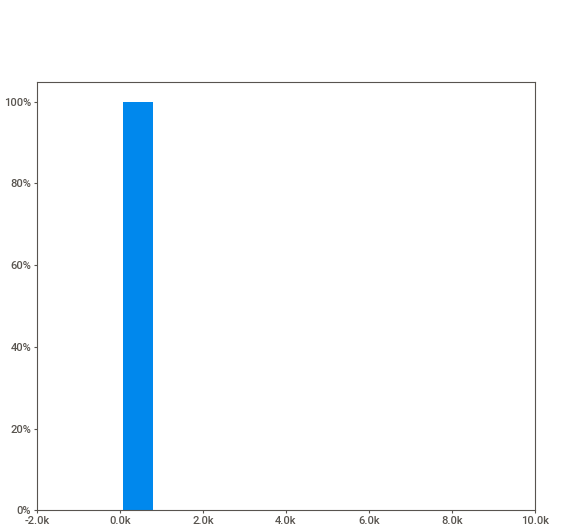
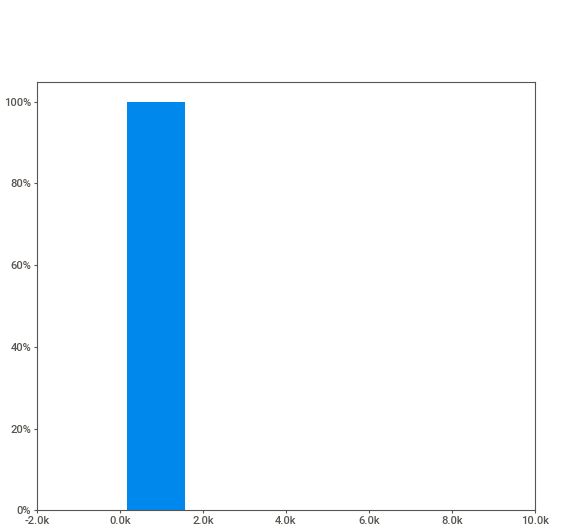
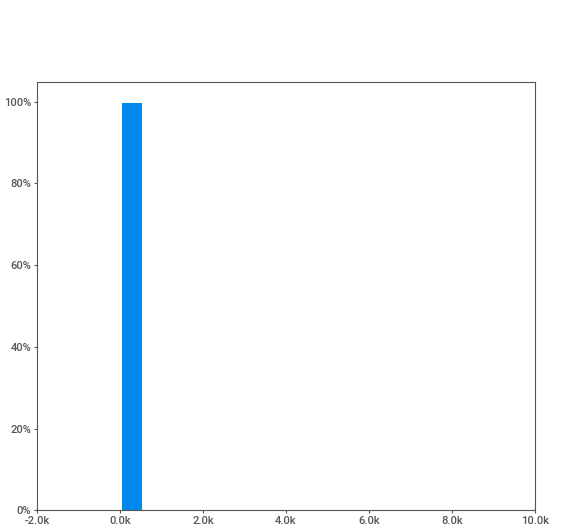
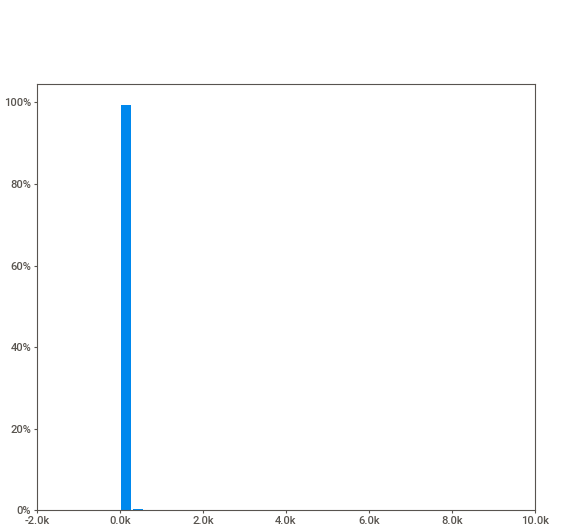
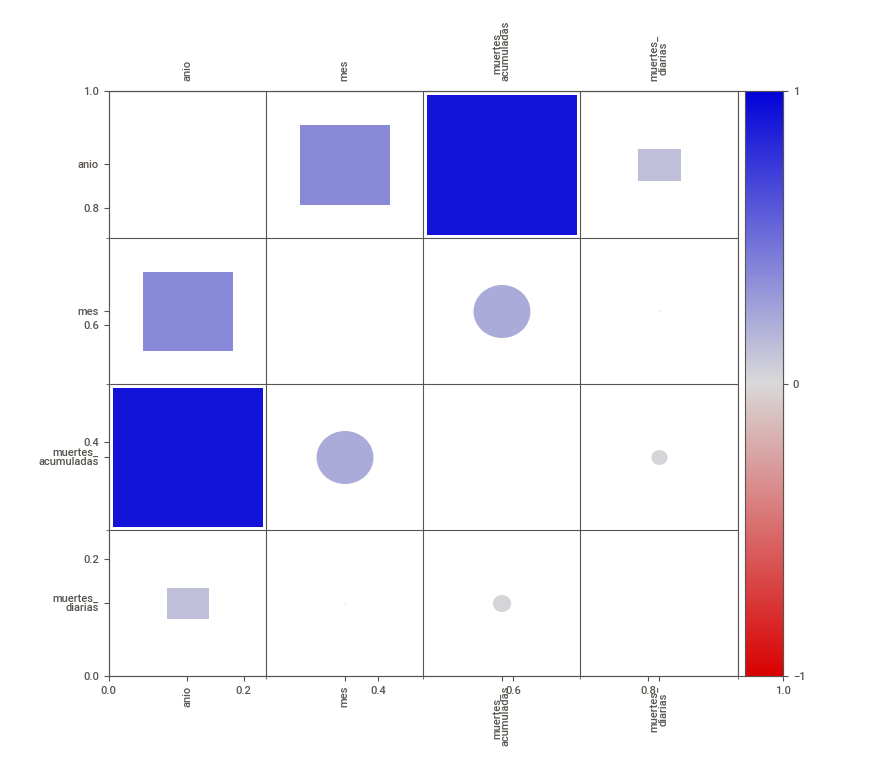
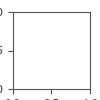

In [52]:
#eeporte 2: covid_deaths_ecuador
rep_covid = sv.analyze(df_covid)
rep_covid.show_html("/content/drive/Shared drives/ETL_final_delivery/" + "sweetviz_covid.html", open_browser=False)
print("Reporte tf_covid guardado en Drive ✓")
rep_covid.show_notebook()

                                             |          | [  0%]   00:00 -> (? left)

Report /content/drive/Shared drives/ETL_final_delivery/sweetviz_uhc.html was generated.
Reporte tf_uhc guardado en Drive ✓



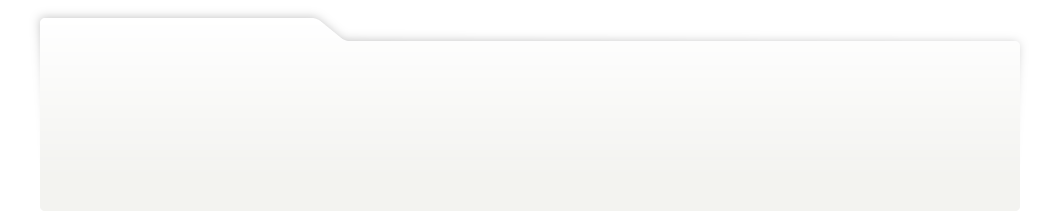
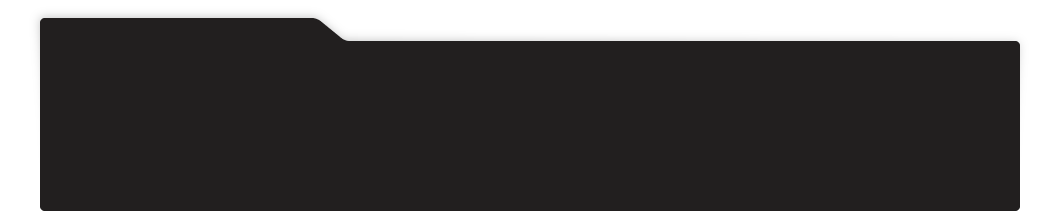
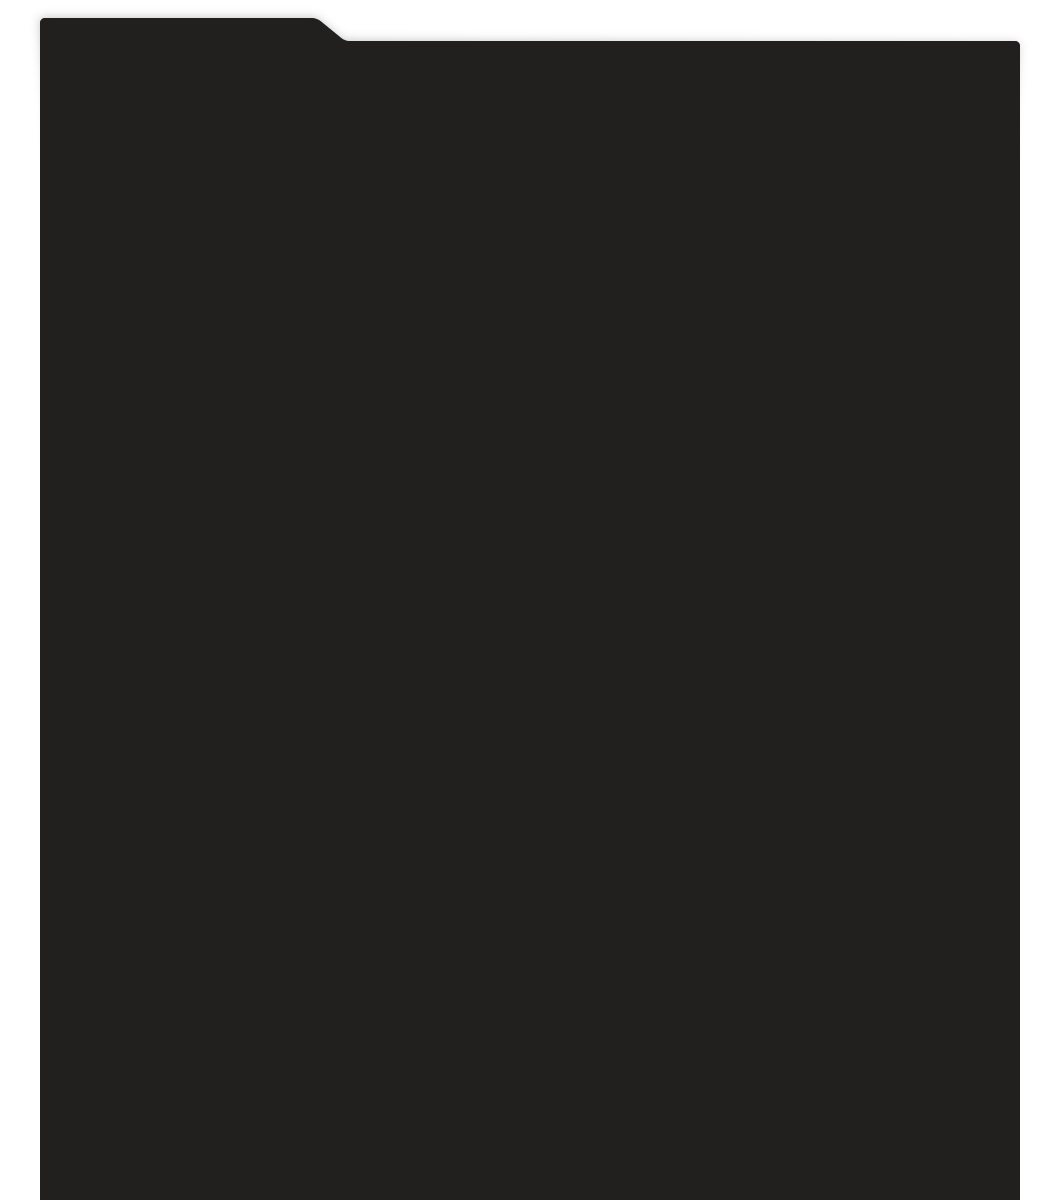
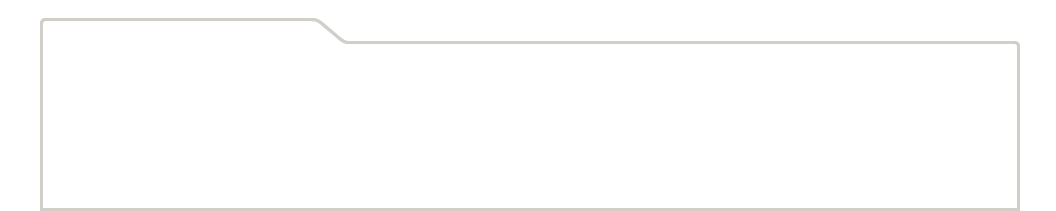
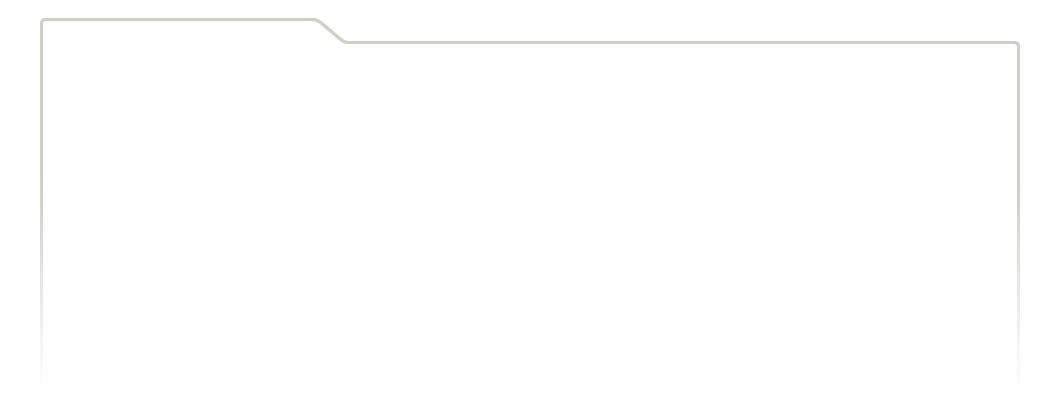
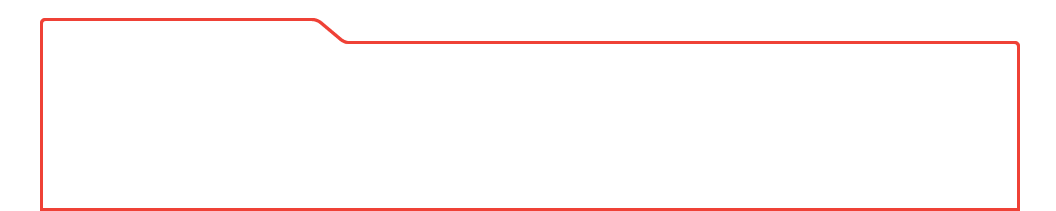
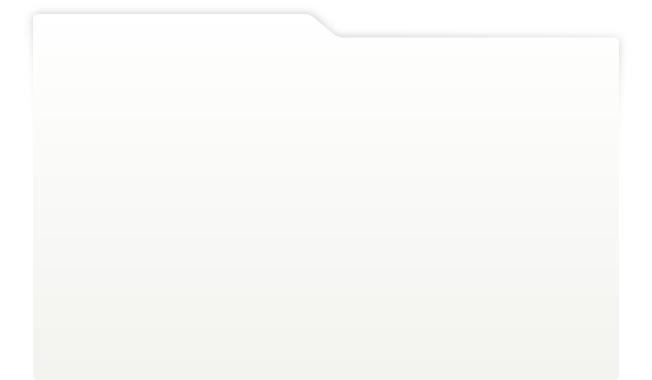
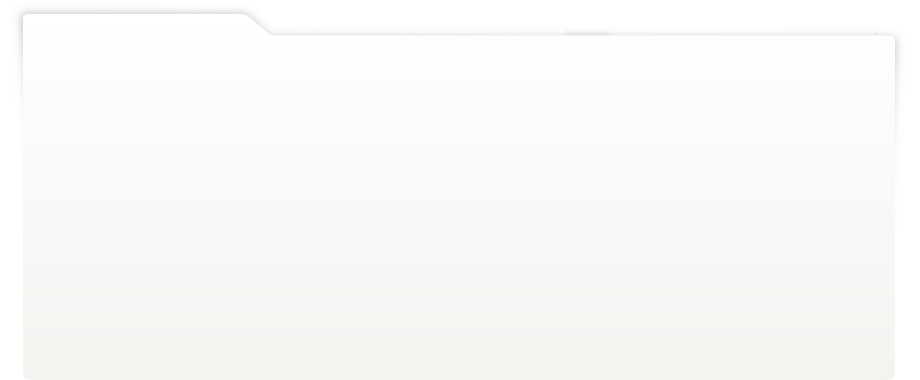
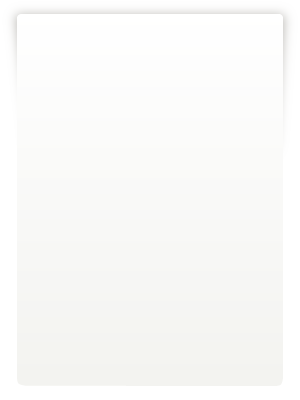
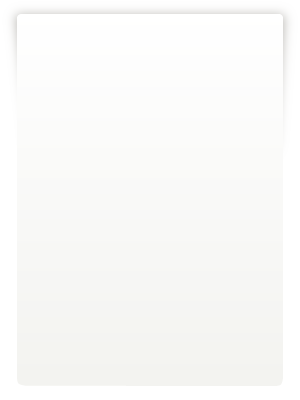
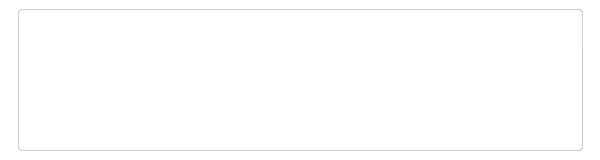
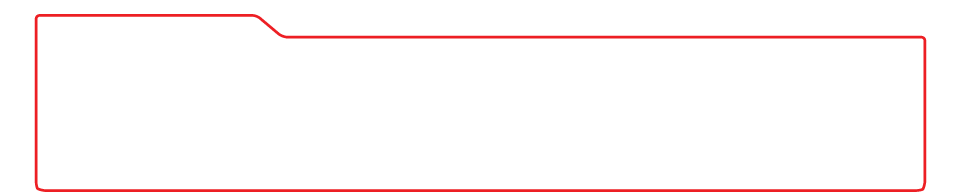
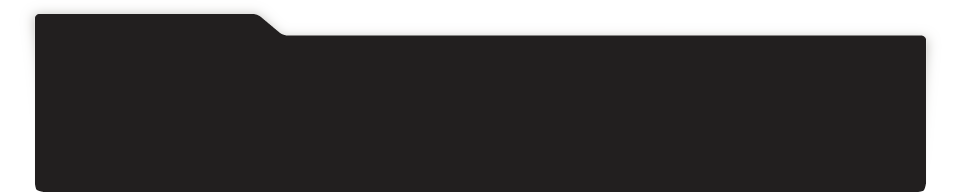
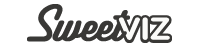
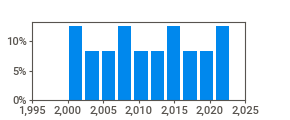
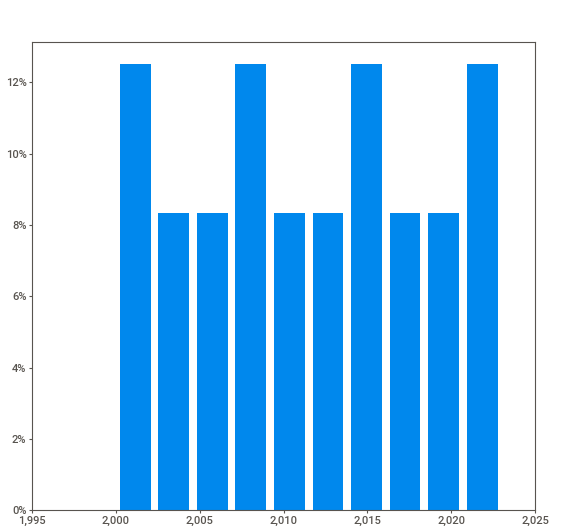
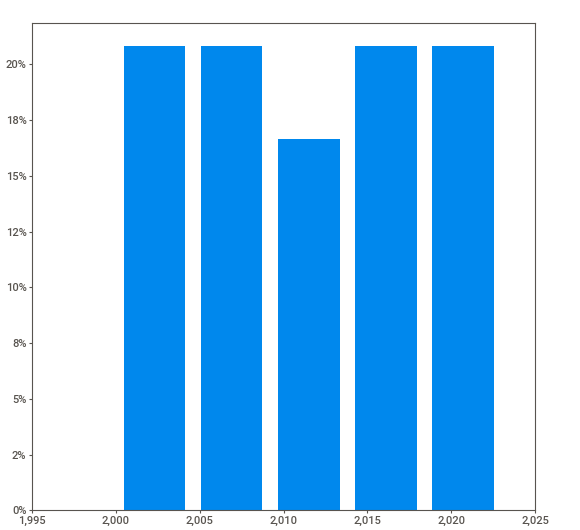
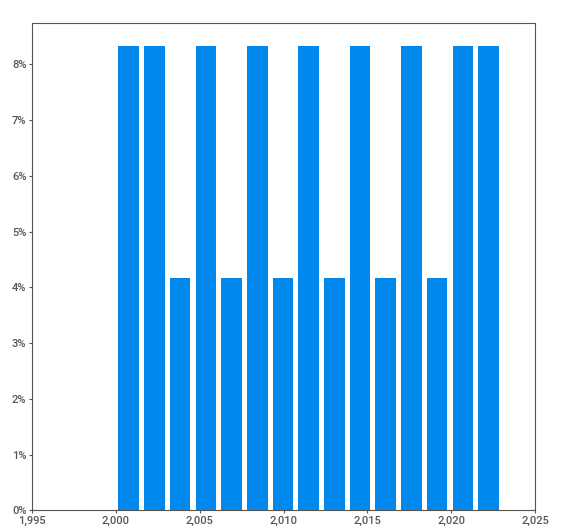
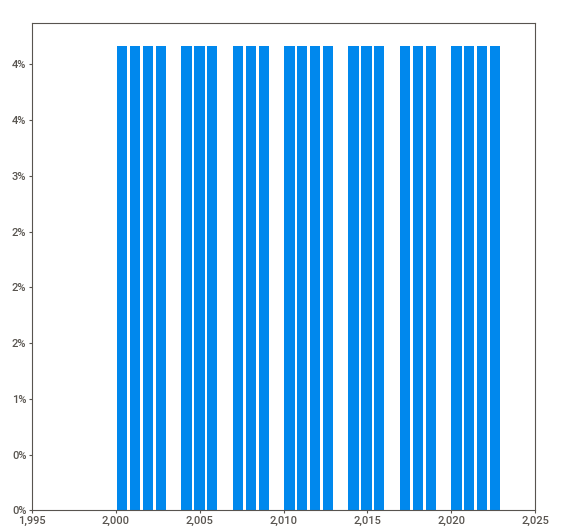
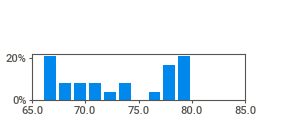
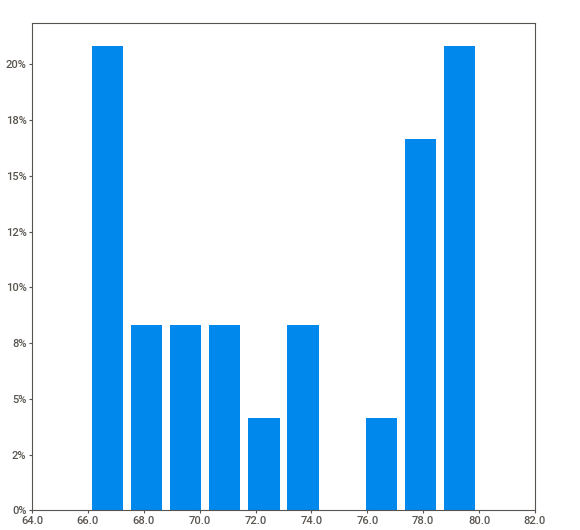
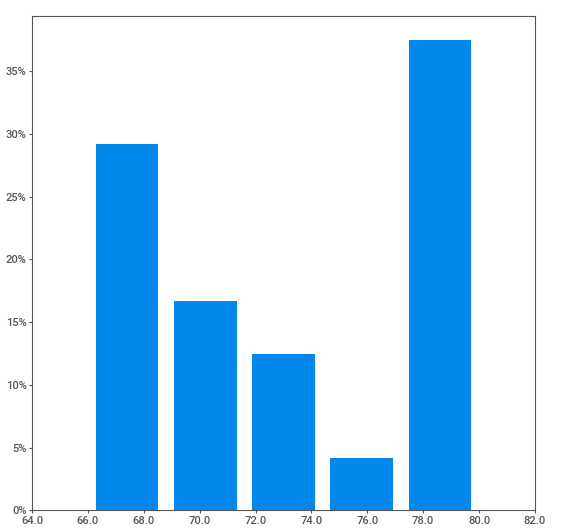
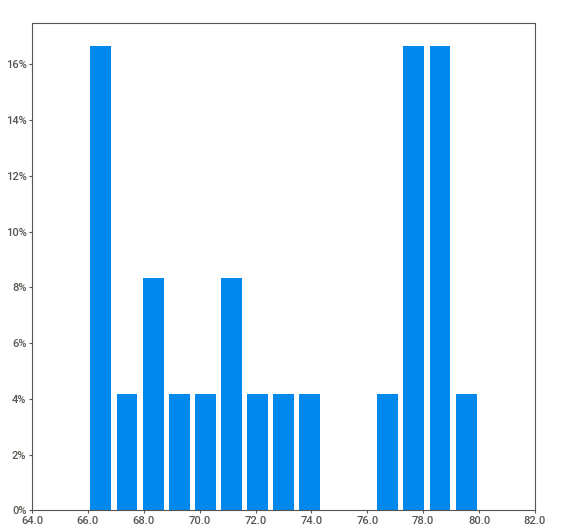
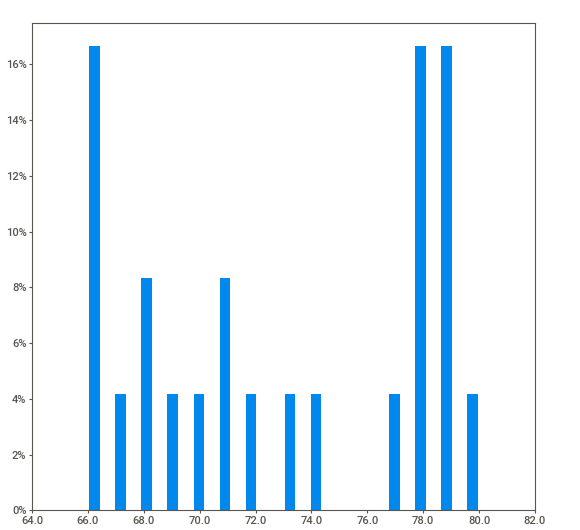
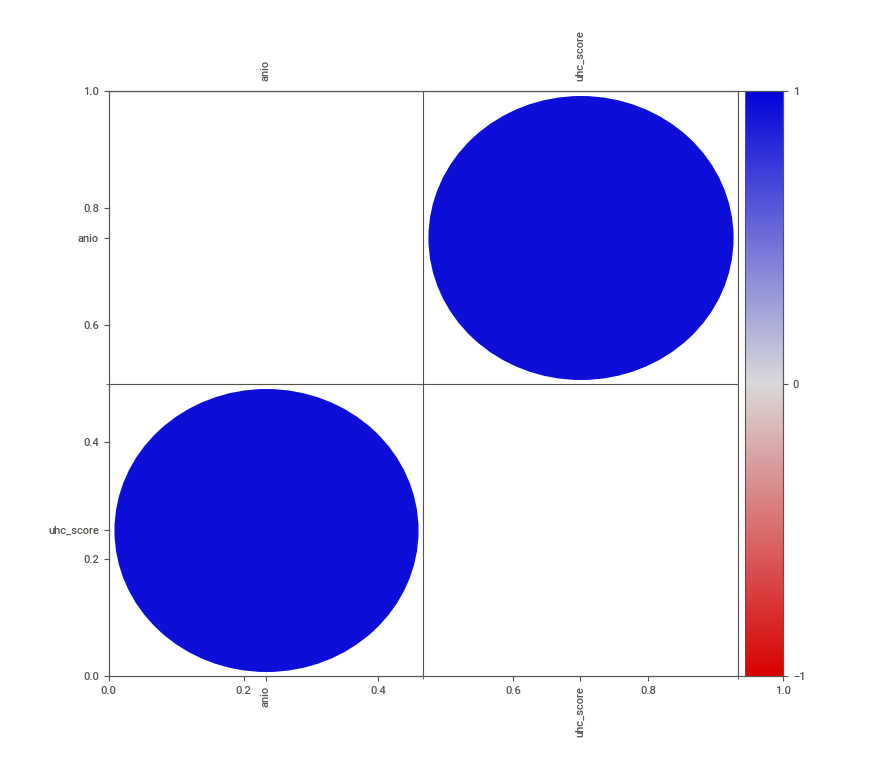
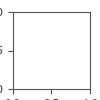

In [53]:
#Reporte 3: uhc_index_ecuador
rep_uhc = sv.analyze(df_uhc)
rep_uhc.show_html("/content/drive/Shared drives/ETL_final_delivery/" + "sweetviz_uhc.html", open_browser=False)
print("Reporte tf_uhc guardado en Drive ✓")
rep_uhc.show_notebook()

---
##Analisis -> Variables de Dosis

Exploramos la distribución de cada tipo de dosis en `tf_fact` mediante histogramas y boxplots.

In [54]:
dosis_cols = ["dosis_total", "primera_dosis", "segunda_dosis",
              "dosis_unica", "dosis_refuerzo"]

# Estadisticas descriptivas
print("\n Estadisticas descriptivas — variables de dosis")
print(df_fact[dosis_cols].describe().applymap(lambda x: f"{x:,.0f}"))


 Estadisticas descriptivas — variables de dosis
      dosis_total primera_dosis segunda_dosis dosis_unica dosis_refuerzo
count      66,320        66,320        66,320      66,320         66,320
mean       57,080        32,700        23,314         589            477
std       263,230       142,360       117,318       3,198          5,388
min             1             0             0           0              0
25%         2,777         2,040           554           0              0
50%        12,546         7,942         3,888           0              0
75%        39,195        23,158        15,134         180              0
max     4,956,326     2,337,173     2,283,263      61,994        286,080


---
##Análisis Temporal COVID-19

Visualizacion la evolución de muertes COVID en el tiempo.

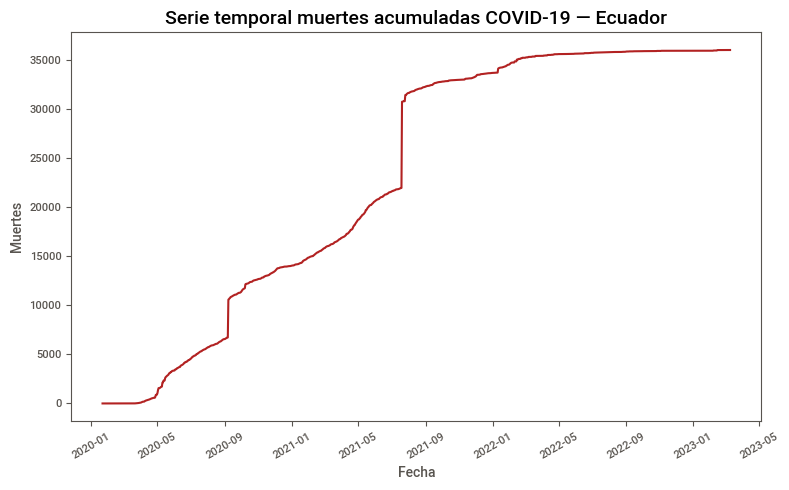

Serie temporal COVID guardada


In [55]:
df_cv = df_covid.copy()
df_cv["fecha"] = pd.to_datetime(df_cv["fecha"])

plt.figure(figsize=(8, 5))
plt.title("Serie temporal muertes acumuladas COVID-19 — Ecuador", fontsize=14, fontweight="bold")

# Muertes acumuladas
plt.plot(df_cv["fecha"], df_cv["muertes_acumuladas"],
         color="firebrick", linewidth=1.5)
plt.xticks(rotation=30)
plt.xlabel("Fecha")
plt.ylabel("Muertes")

plt.tight_layout()
plt.savefig(ruta + "eda_covid_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Serie temporal COVID guardada")

---
##UHC Score - Evolución del Índice de Cobertura Sanitaria

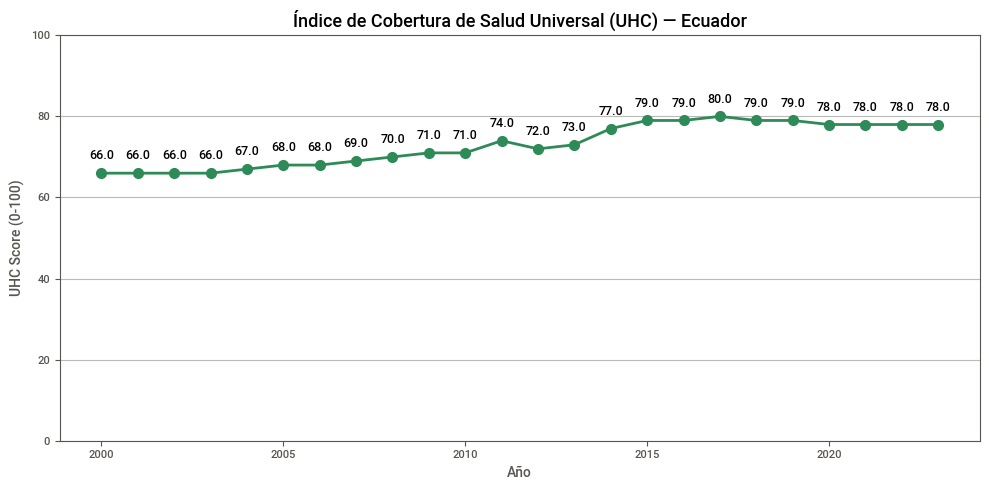

Gráfico UHC Score guardado

Último año disponible: 2023
Último UHC Score: 78.0
Tendencia: variable


In [56]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_uhc["anio"], df_uhc["uhc_score"],
        marker="o", color="seagreen", linewidth=2, markersize=7)

# Añadir etiquetas de valor
for _, row in df_uhc.iterrows():
    ax.annotate(f"{row['uhc_score']:.1f}",
                (row["anio"], row["uhc_score"]),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9)

ax.set_title("Índice de Cobertura de Salud Universal (UHC) — Ecuador",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("UHC Score (0-100)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig(ruta + "eda_uhc_score.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico UHC Score guardado")

print(f"\nÚltimo año disponible: {df_uhc['anio'].max()}")
print(f"Último UHC Score: {df_uhc.loc[df_uhc['anio'].idxmax(), 'uhc_score']:.1f}")
print(f"Tendencia: {'creciente ↑' if df_uhc['uhc_score'].is_monotonic_increasing else 'variable'}")

# Distribucion y boxplot

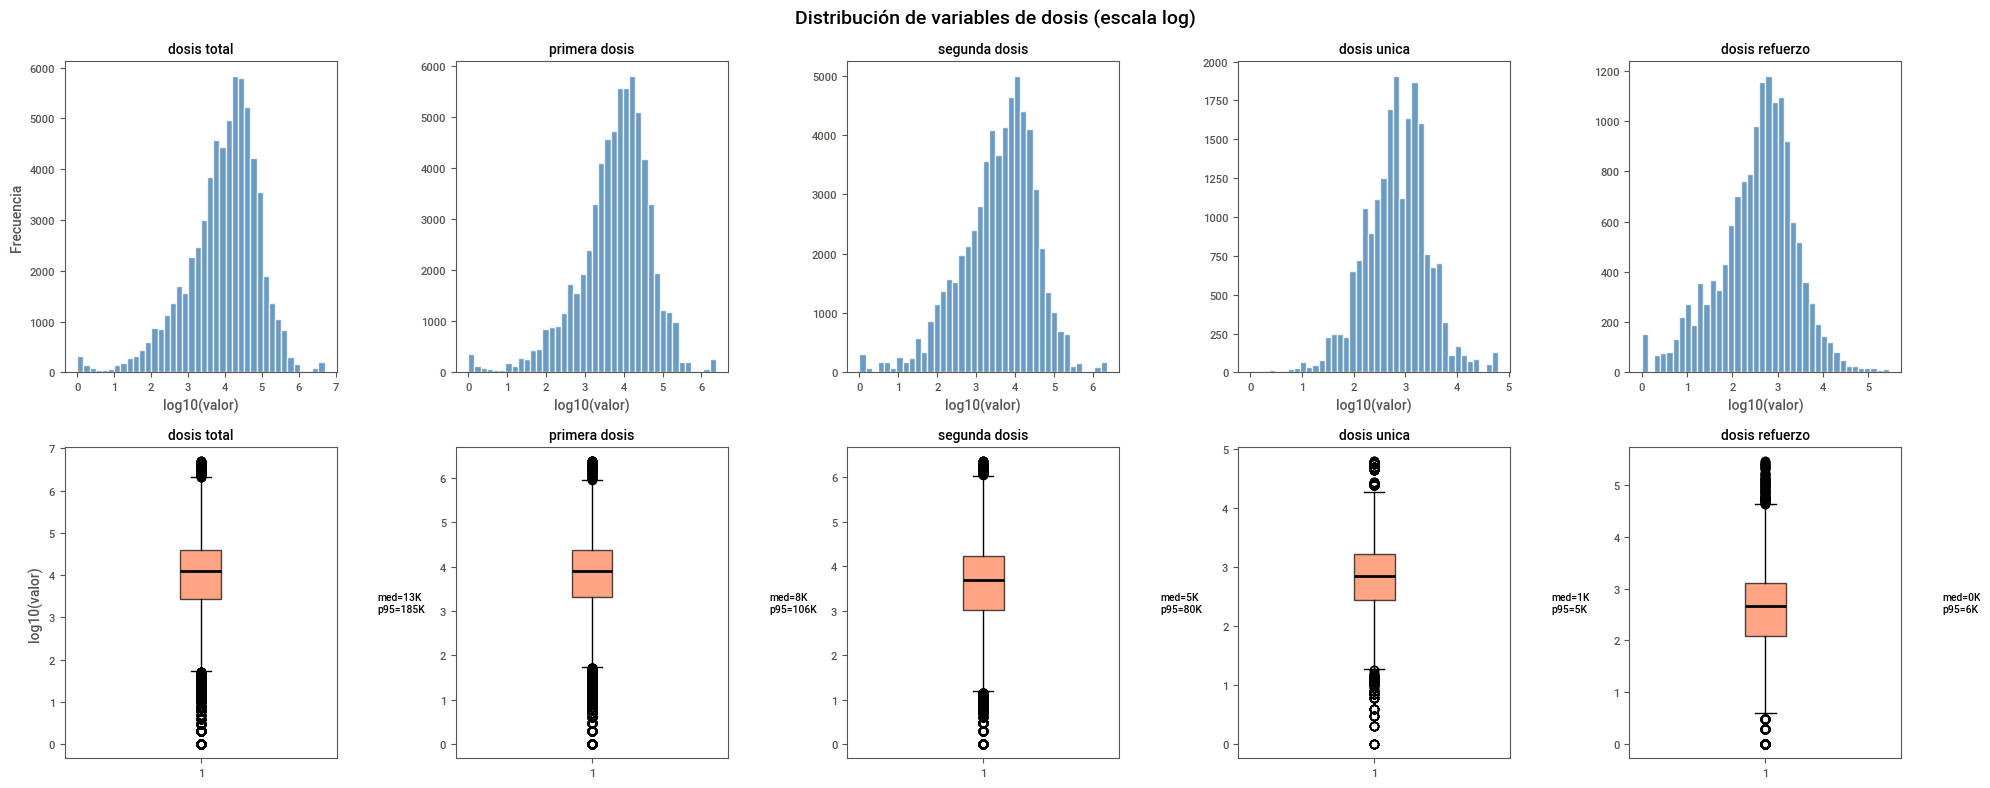

Distribuciones guardadas


In [57]:
dosis_cols = ["dosis_total","primera_dosis","segunda_dosis","dosis_unica","dosis_refuerzo"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Distribución de variables de dosis (escala log)",
             fontsize=14, fontweight="bold")

for i, col in enumerate(dosis_cols):
    serie = df_fact[col][df_fact[col] > 0]  # log requiere > 0

    # Histograma log
    axes[0, i].hist(np.log10(serie), bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    axes[0, i].set_title(col.replace("_", " "), fontsize=10)
    axes[0, i].set_xlabel("log10(valor)")
    axes[0, i].set_ylabel("Frecuencia" if i == 0 else "")

    # Boxplot log
    axes[1, i].boxplot(np.log10(serie), patch_artist=True,
                       boxprops=dict(facecolor="coral", alpha=0.7),
                       medianprops=dict(color="black", linewidth=2))
    axes[1, i].set_title(col.replace("_", " "), fontsize=10)
    axes[1, i].set_ylabel("log10(valor)" if i == 0 else "")

    # Anotar mediana y p95
    med = serie.median()
    p95 = serie.quantile(0.95)
    axes[1, i].annotate(f"med={med/1e3:.0f}K\np95={p95/1e3:.0f}K",
                        xy=(1.15, 0.5), xycoords="axes fraction",
                        fontsize=7.5, va="center")

plt.tight_layout()
plt.savefig(ruta + "eda_distribuciones_dosis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Distribuciones guardadas")


# **Dashboard Estatico**

In [58]:
ruta_dwh_final_delivery = "/content/drive/Shared drives/ETL_final_delivery/dwh_final_delivery.db"

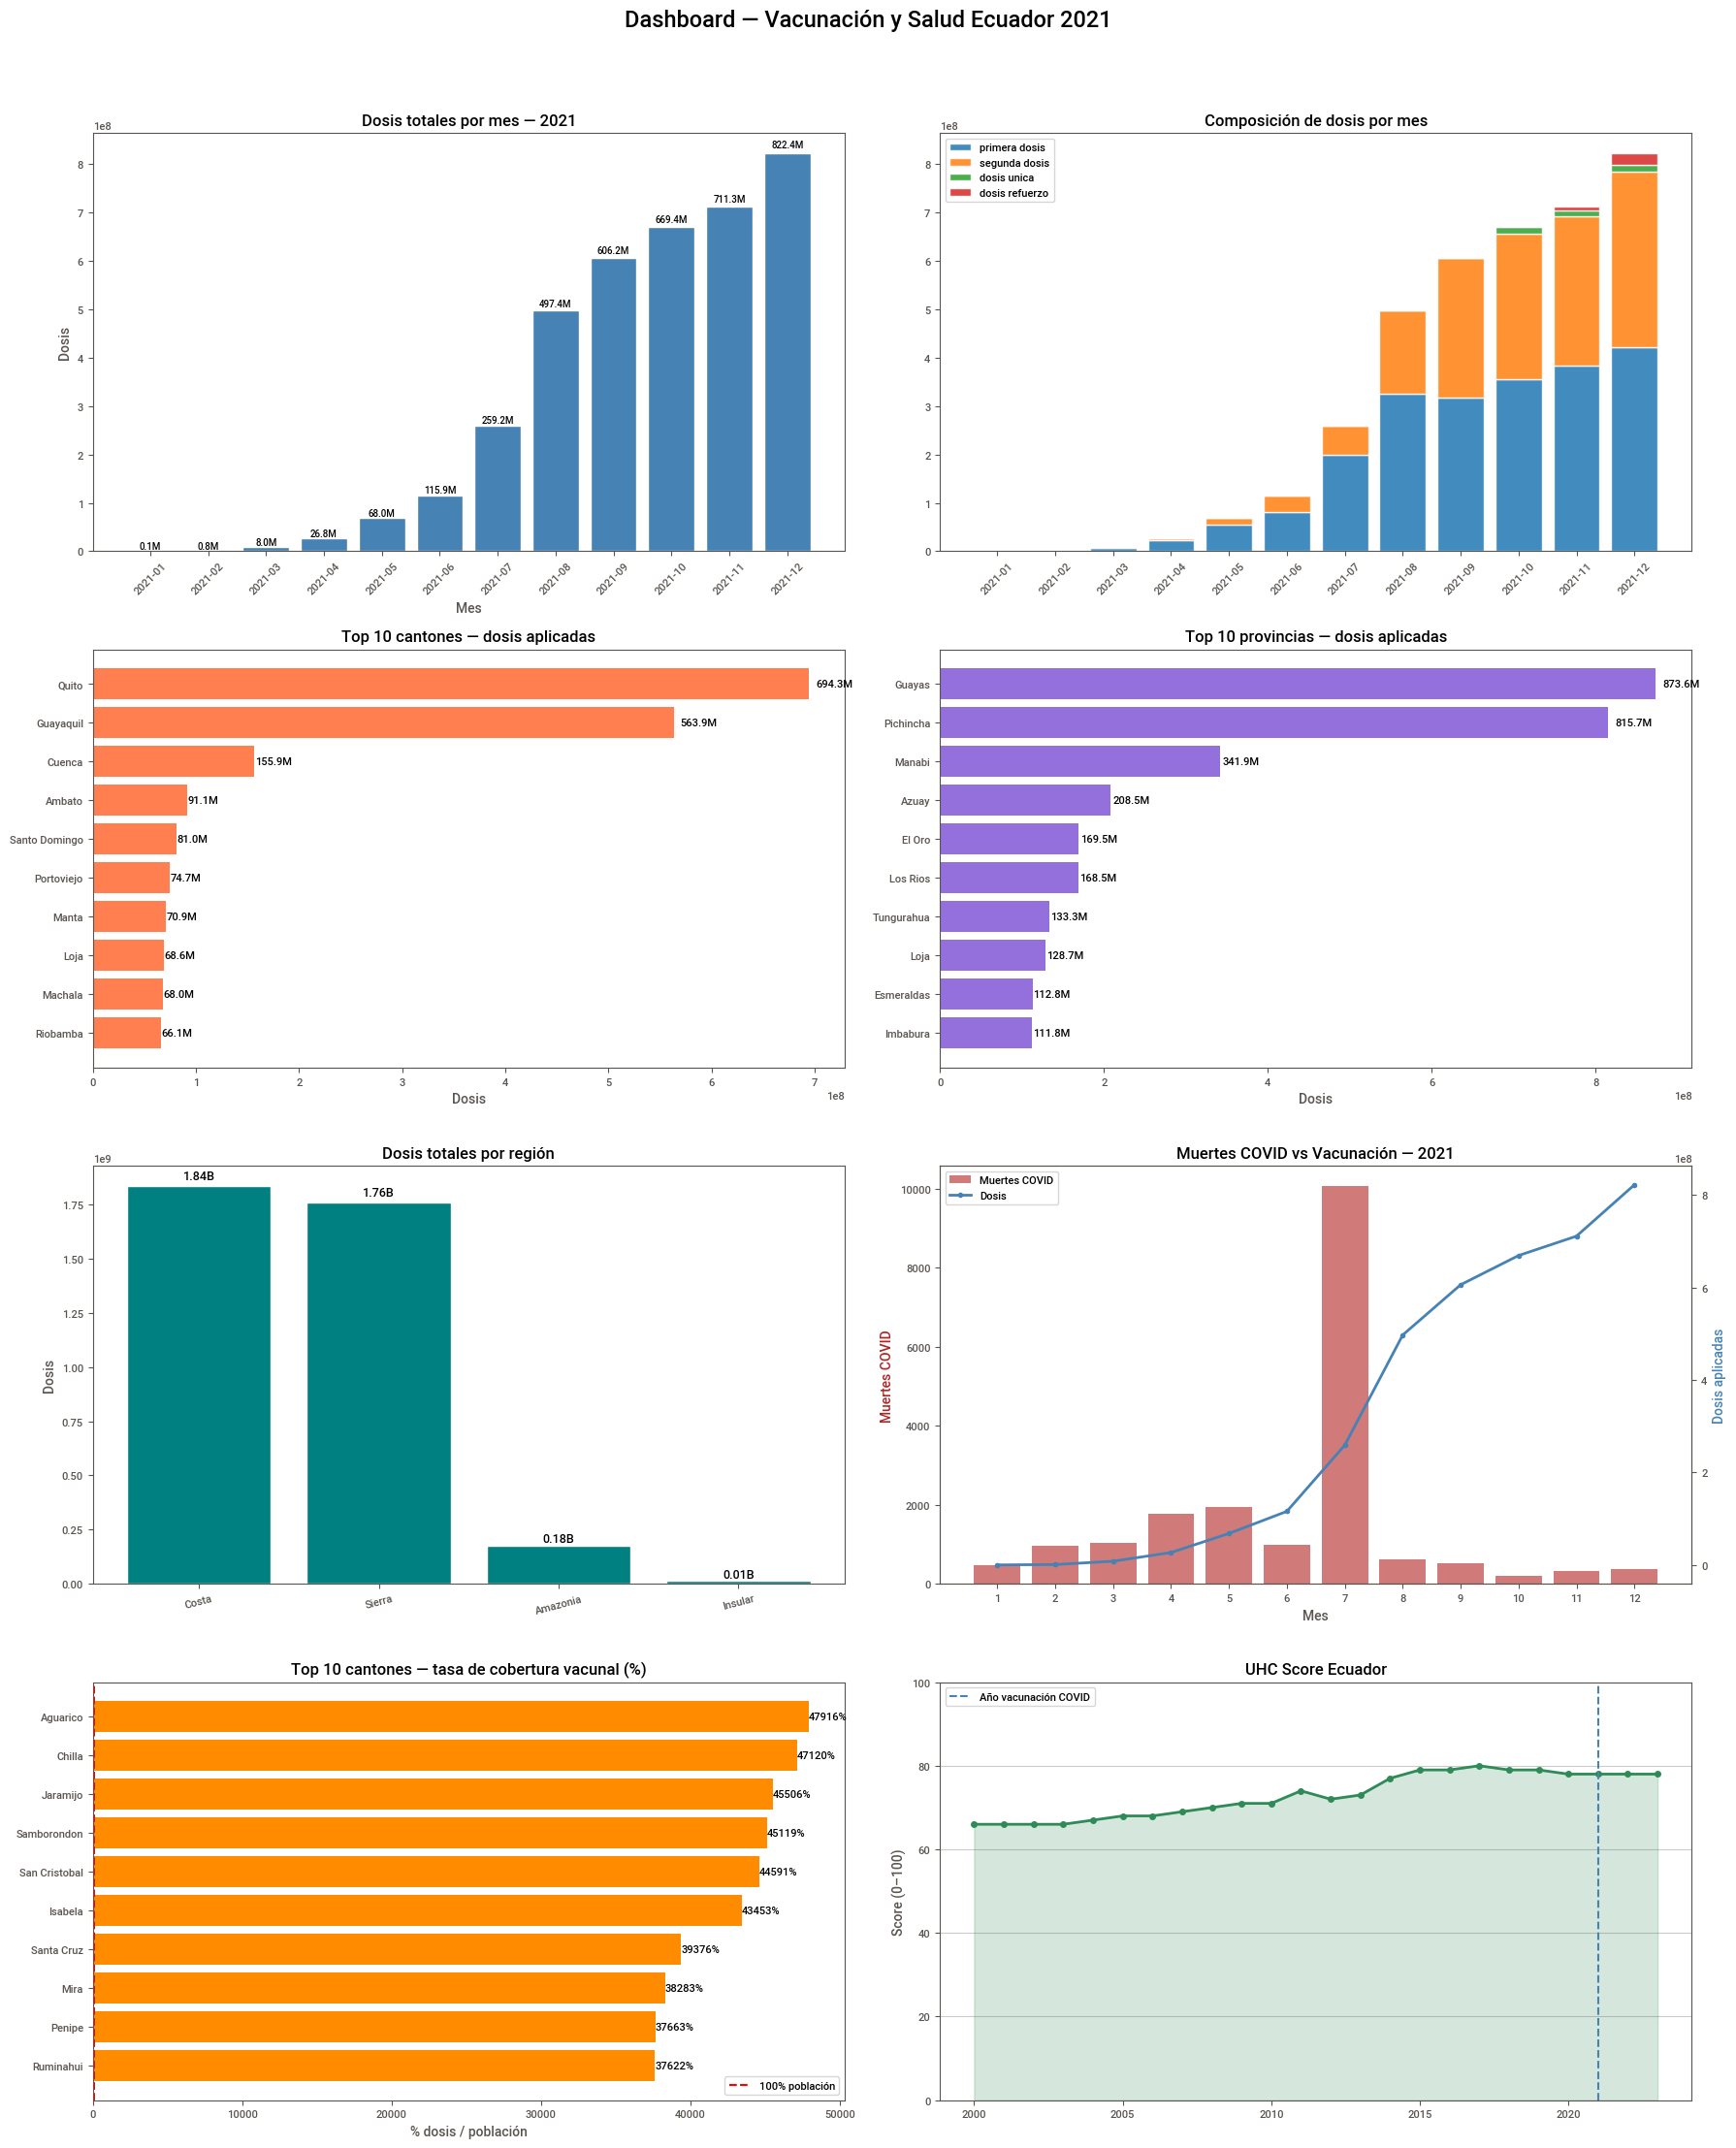

Dashboard generado correctamente.


In [59]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sqlite3
import os

# Conexión
conn = sqlite3.connect(ruta_dwh_final_delivery)

fig = plt.figure(figsize=(18, 22))
fig.suptitle("Dashboard — Vacunación y Salud Ecuador 2021",
             fontsize=17, fontweight="bold", y=1.005)

#1) Evolución mensual de dosis totales
ax1 = fig.add_subplot(4, 2, 1)
df_mensual = pd.read_sql("""
    SELECT d.anio, d.mes, SUM(f.dosis_total) AS dosis_total
    FROM fact_vacunacion f
    JOIN dim_fecha d ON f.date_id = d.id
    WHERE d.anio = 2021
    GROUP BY d.anio, d.mes
    ORDER BY d.anio, d.mes
""", conn)

df_mensual["periodo"] = (
    df_mensual["anio"].astype(str) + "-" + df_mensual["mes"].astype(str).str.zfill(2)
)

bars = ax1.bar(
    df_mensual["periodo"],
    df_mensual["dosis_total"],
    color="steelblue",
    edgecolor="white"
)
ax1.set_title("Dosis totales por mes — 2021")
ax1.set_xlabel("Mes")
ax1.set_ylabel("Dosis")
ax1.tick_params(axis="x", rotation=45)

for bar, val in zip(bars, df_mensual["dosis_total"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f"{val/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=7)


#2) Composición de dosis por mes (apilado) ─
ax2 = fig.add_subplot(4, 2, 2)
df_comp = pd.read_sql("""
    SELECT d.anio, d.mes,
           SUM(f.primera_dosis)  AS primera_dosis,
           SUM(f.segunda_dosis)  AS segunda_dosis,
           SUM(f.dosis_unica)    AS dosis_unica,
           SUM(f.dosis_refuerzo) AS dosis_refuerzo
    FROM fact_vacunacion f
    JOIN dim_fecha d ON f.date_id = d.id
    WHERE d.anio = 2021
    GROUP BY d.anio, d.mes
    ORDER BY d.anio, d.mes
""", conn)

df_comp["periodo"] = (
    df_comp["anio"].astype(str) + "-" + df_comp["mes"].astype(str).str.zfill(2)
)

tipo_cols = ["primera_dosis", "segunda_dosis", "dosis_unica", "dosis_refuerzo"]
colors_stk = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

bottom = np.zeros(len(df_comp))
for col, color in zip(tipo_cols, colors_stk):
    ax2.bar(
        df_comp["periodo"],
        df_comp[col],
        bottom=bottom,
        label=col.replace("_", " "),
        color=color,
        alpha=0.85,
        edgecolor="white"
    )
    bottom += df_comp[col].fillna(0).values

ax2.set_title("Composición de dosis por mes")
ax2.tick_params(axis="x", rotation=45)
ax2.legend(fontsize=8)


#3) Top 10 cantones — dosis totales
ax3 = fig.add_subplot(4, 2, 3)
df_canton = pd.read_sql("""
    SELECT c.canton_nombre, SUM(f.dosis_total) AS total
    FROM fact_vacunacion f
    JOIN dim_canton c ON f.canton_id = c.canton_id
    WHERE EXISTS (
        SELECT 1
        FROM dim_fecha d
        WHERE d.id = f.date_id AND d.anio = 2021
    )
    GROUP BY c.canton_nombre
    ORDER BY total DESC
    LIMIT 10
""", conn)

ax3.barh(df_canton["canton_nombre"][::-1], df_canton["total"][::-1], color="coral")
ax3.set_title("Top 10 cantones — dosis aplicadas")
ax3.set_xlabel("Dosis")

for i, val in enumerate(df_canton["total"][::-1]):
    ax3.text(val * 1.01, i, f"{val/1e6:.1f}M", va="center", fontsize=8)

#4) Top 10 provincias — dosis totales
ax4 = fig.add_subplot(4, 2, 4)
df_prov = pd.read_sql("""
    SELECT p.provincia_nombre, SUM(f.dosis_total) AS total
    FROM fact_vacunacion f
    JOIN dim_provincia p ON f.provincia_id = p.id
    WHERE EXISTS (
        SELECT 1
        FROM dim_fecha d
        WHERE d.id = f.date_id AND d.anio = 2021
    )
    GROUP BY p.provincia_nombre
    ORDER BY total DESC
    LIMIT 10
""", conn)

ax4.barh(df_prov["provincia_nombre"][::-1], df_prov["total"][::-1], color="mediumpurple")
ax4.set_title("Top 10 provincias — dosis aplicadas")
ax4.set_xlabel("Dosis")

for i, val in enumerate(df_prov["total"][::-1]):
    ax4.text(val * 1.01, i, f"{val/1e6:.1f}M", va="center", fontsize=8)

#5) Dosis totales por región
ax5 = fig.add_subplot(4, 2, 5)
df_region = pd.read_sql("""
    SELECT r.region_nombre, SUM(f.dosis_total) AS total
    FROM fact_vacunacion f
    JOIN dim_region r ON f.region_id = r.id
    WHERE EXISTS (
        SELECT 1
        FROM dim_fecha d
        WHERE d.id = f.date_id AND d.anio = 2021
    )
    GROUP BY r.region_nombre
    ORDER BY total DESC
""", conn)

bars5 = ax5.bar(df_region["region_nombre"], df_region["total"], color="teal", edgecolor="white")
ax5.set_title("Dosis totales por región")
ax5.set_ylabel("Dosis")
ax5.tick_params(axis="x", rotation=15)

for bar, val in zip(bars5, df_region["total"]):
    ax5.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f"{val/1e9:.2f}B",
        ha="center",
        va="bottom",
        fontsize=9
    )

#6) Muertes COVID mensual 2021 vs Vacunación
ax6 = fig.add_subplot(4, 2, 6)
df_covid_m = pd.read_sql("""
    SELECT d.mes, SUM(f.muertes_diarias) AS muertes
    FROM fact_decesos f
    JOIN dim_fecha d ON f.date_id = d.id
    WHERE d.anio = 2021
    GROUP BY d.mes
    ORDER BY d.mes
""", conn)

ax6b = ax6.twinx()
ax6.bar(
    df_covid_m["mes"],
    df_covid_m["muertes"],
    color="firebrick",
    alpha=0.6,
    label="Muertes COVID"
)
ax6b.plot(
    df_mensual["mes"],
    df_mensual["dosis_total"],
    color="steelblue",
    marker="o",
    linewidth=2,
    label="Dosis"
)

ax6.set_title("Muertes COVID vs Vacunación — 2021")
ax6.set_xlabel("Mes")
ax6.set_ylabel("Muertes COVID", color="firebrick")
ax6b.set_ylabel("Dosis aplicadas", color="steelblue")
ax6.set_xticks(range(1, 13))

lines1, labels1 = ax6.get_legend_handles_labels()
lines2, labels2 = ax6b.get_legend_handles_labels()
ax6.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")

#7) Tasa de cobertura vacunal por cantón (top 10)
ax7 = fig.add_subplot(4, 2, 7)
df_cob = pd.read_sql("""
    SELECT c.canton_nombre,
           ROUND(100.0 * SUM(f.dosis_total) / NULLIF(MAX(f.poblacion_canton), 0), 1) AS cobertura_pct
    FROM fact_vacunacion f
    JOIN dim_canton c ON f.canton_id = c.canton_id
    WHERE EXISTS (
        SELECT 1
        FROM dim_fecha d
        WHERE d.id = f.date_id AND d.anio = 2021
    )
    GROUP BY c.canton_nombre
    ORDER BY cobertura_pct DESC
    LIMIT 10
""", conn)

ax7.barh(df_cob["canton_nombre"][::-1], df_cob["cobertura_pct"][::-1], color="darkorange")
ax7.axvline(x=100, color="red", linestyle="--", linewidth=1.5, label="100% población")
ax7.set_title("Top 10 cantones — tasa de cobertura vacunal (%)")
ax7.set_xlabel("% dosis / población")
ax7.legend(fontsize=8)

for i, val in enumerate(df_cob["cobertura_pct"][::-1]):
    ax7.text(val + 1, i, f"{val:.0f}%", va="center", fontsize=8)

#8) UHC Score Ecuador histórico
ax8 = fig.add_subplot(4, 2, 8)
df_uhc_hist = pd.read_sql("""
    SELECT anio, uhc_score
    FROM dim_indice_uhc
    ORDER BY anio
""", conn)

ax8.fill_between(df_uhc_hist["anio"], df_uhc_hist["uhc_score"], alpha=0.2, color="seagreen")
ax8.plot(
    df_uhc_hist["anio"],
    df_uhc_hist["uhc_score"],
    marker="o",
    color="seagreen",
    linewidth=2,
    markersize=4
)
ax8.axvline(x=2021, color="steelblue", linestyle="--", linewidth=1.5, label="Año vacunación COVID")
ax8.set_title("UHC Score Ecuador")
ax8.set_ylabel("Score (0–100)")
ax8.set_ylim(0, 100)
ax8.legend(fontsize=8)
ax8.grid(axis="y", alpha=0.3)

conn.close()
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

print("Dashboard generado correctamente.")